# Biased Blocks

Flexible biased-block notebook. Build views by genotype, line, cohort, dataset, animal, or custom combinations, prepare the block-labeled RT tables once, then choose a plot layout without recomputing.

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Datasets

`DATASET_SELECTIONS` is the safest option when mixing lines/cohorts. Use `ANIMAL_SELECTION` for a one-animal review.

In [2]:
LINES = ["SHANK3"]
COHORTS = ["cohort1"]

# Explicit selections can mix lines/cohorts, e.g.:
# DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
DATASET_SELECTIONS = [("SHANK3", "cohort1")]

# Optional: restrict to one animal, e.g. "ASD0041". Use None for all animals.
ANIMAL_SELECTION = None

## 3. Choose Comparison

Common presets:

- Compare genotypes within selected datasets: `COMPARISON = "genotypes"`, `SPLIT_BY = "none"`
- Keep cohorts/datasets separate within genotype: `COMPARISON = "genotypes"`, `SPLIT_BY = "dataset"`
- Compare the same genotype across datasets: `COMPARISON = "datasets"`, `GENOTYPES = ["hom"]`
- One view per animal: `COMPARISON = "animals"`
- Fully custom: `COMPARISON = "custom"` and edit `CUSTOM_SPECS`.

In [3]:
COMPARISON = "genotypes"  # "genotypes", "datasets", "lines", "cohorts", "animals", or "custom"
SPLIT_BY = "none"         # for COMPARISON="genotypes": "none", "dataset", "line", or "cohort"
GENOTYPES = ["wt", "het", "hom"]

CUSTOM_SPECS = [
    # {"name": "SHANK3 hom", "line": "SHANK3", "genotype": "hom"},
    # {"name": "ASD0041", "animal": "ASD0041"},
]

## 4. Load Data And Build Views

Rerun this if you change dataset selection, comparison mode, genotype selection, animal selection, or custom specs.

In [4]:
from GroupComparison.config import ViewSpec
from Pipeline.group_comparison import (
    build_group_views,
    build_view_style_maps,
    load_groupcomparison_data,
    make_selector,
    summarize_views,
)


data = load_groupcomparison_data(
    lines=LINES,
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
)
df_plot = data["df_plot"].copy()

if ANIMAL_SELECTION is not None:
    df_plot = df_plot[df_plot["animal"].astype(str).str.strip() == str(ANIMAL_SELECTION)].copy()

if COMPARISON == "animals":
    views = [
        ViewSpec(str(animal), lambda d, _animal=str(animal): d[d["animal"].astype(str).str.strip() == _animal].copy())
        for animal in sorted(df_plot["animal"].dropna().astype(str).unique())
    ]
elif COMPARISON == "custom" and CUSTOM_SPECS:
    views = []
    for spec in CUSTOM_SPECS:
        if "animal" in spec:
            views.append(ViewSpec(spec["name"], lambda d, _animal=str(spec["animal"]): d[d["animal"].astype(str).str.strip() == _animal].copy()))
        else:
            views.append(
                ViewSpec(
                    spec["name"],
                    make_selector(
                        genotypes=spec.get("genotypes", spec.get("genotype")),
                        lines=spec.get("lines", spec.get("line")),
                        cohorts=spec.get("cohorts", spec.get("cohort")),
                        dataset_keys=spec.get("dataset_keys", spec.get("dataset_key")),
                    ),
                )
            )
else:
    views = build_group_views(
        df_plot,
        comparison=COMPARISON,
        split_by=SPLIT_BY,
        genotypes=GENOTYPES,
        custom_specs=CUSTOM_SPECS,
    )

print("Loaded datasets:", data["selections"])
print("Usable dataset keys:", data["usable_dataset_names"])
display(summarize_views(df_plot, views))

view_colors, view_styles = build_view_style_maps(df_plot, views)
print("View colors:", view_colors)
print("View styles:", view_styles)

Loaded datasets: [('SHANK3', 'cohort1')]
Usable dataset keys: ['SHANK3:cohort1']


,view,rows,animals,lines,cohorts,genotypes
0,wt,219982,5,SHANK3,cohort1,wt
1,het,157800,3,SHANK3,cohort1,het
2,hom,314222,6,SHANK3,cohort1,hom


View colors: {'wt': '#4D4D4D', 'het': '#7A8F28', 'hom': '#C24A7A'}
View styles: {'wt': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'het': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}, 'hom': {'linestyle': '-', 'marker': 'o', 'markerfacecolor': None}}


## 5. Prepare Once

This is the expensive step. Rerun it if you change filters, block-label settings, views, or datasets. You do not need to rerun it just to change `LAYOUT` below.

In [8]:
import Pipeline.biased_blocks as bb

BIASED_SESSION_TYPES = (3, 23)
UNBIASED_RT_SESSION_TYPES = (1, 2)
SHORT_DURATION_VALUE = None  # examples: 0, [0, 8, 16, 32, 64, 120], or None for all
RIGHTWARD_ILD_SIGN = 1
MIN_DIRECTION_IMBALANCE = 0.0
KEEP_ONLY_ANIMALS_WITH_BIASED_SESSIONS = True

cfg = bb.default_config()
fcfg = bb.default_filter_config()
style = bb.default_style()

bundle = bb.prepare_biased_blocks(
    df=df_plot,
    views=views,
    cfg=cfg,
    fcfg=fcfg,
    style=style,
    biased_session_types=BIASED_SESSION_TYPES,
    unbiased_rt_session_types=UNBIASED_RT_SESSION_TYPES,
    short_duration_value=SHORT_DURATION_VALUE,
    rightward_ild_sign=RIGHTWARD_ILD_SIGN,
    min_direction_imbalance=MIN_DIRECTION_IMBALANCE,
    keep_only_animals_with_biased_sessions=KEEP_ONLY_ANIMALS_WITH_BIASED_SESSIONS,
)

print("Filtered rows with block labels:", len(bundle["df_blocks"]))
display(bundle["block_summary"])

Filtered rows with block labels: 532731


,line,cohort,genotype,animal,session_type,block_condition,trials
0,SHANK3,cohort1,het,ASD0038,1,unbiased,23302
1,SHANK3,cohort1,het,ASD0038,2,unbiased,12277
2,SHANK3,cohort1,het,ASD0038,23,leftward,5312
3,SHANK3,cohort1,het,ASD0038,23,rightward,5478
4,SHANK3,cohort1,het,ASD0038,23,unbiased,3337
5,SHANK3,cohort1,het,ASD0039,1,unbiased,18270
6,SHANK3,cohort1,het,ASD0039,2,unbiased,14053
7,SHANK3,cohort1,het,ASD0039,23,leftward,5802
8,SHANK3,cohort1,het,ASD0039,23,rightward,5581
9,SHANK3,cohort1,het,ASD0039,23,unbiased,2206


## 6. Plot From Prepared Data

Change `LAYOUT` and rerun this cell without recomputing preparation.

- `block_conditions`: one figure per block condition; lines are selected genotype/view groups
- `genotype_blocks`: one figure per selected genotype/view; lines are block conditions
- `animal_blocks`: one figure per animal; lines are block conditions
- `block_condition_params`: one psychometric-parameter summary per ABL; markers are genotype/view means ± SEM across animals
- `block_bias`: two bias summary figures, one by animal and one by genotype/view
- `left_to_right_transition`: one figure per genotype/view, 3 ABL panels, signed choice-right traces for both left-to-right and right-to-left transitions in separate panels
- `biased_transition_aligned`: test layout pooling any biased-to-biased transition, aligned to the new favored side
- `biased_transition_collapsed`: test layout pooling any biased-to-biased transition and collapsing ILDs to hard vs easy
- `all`: make all figure families

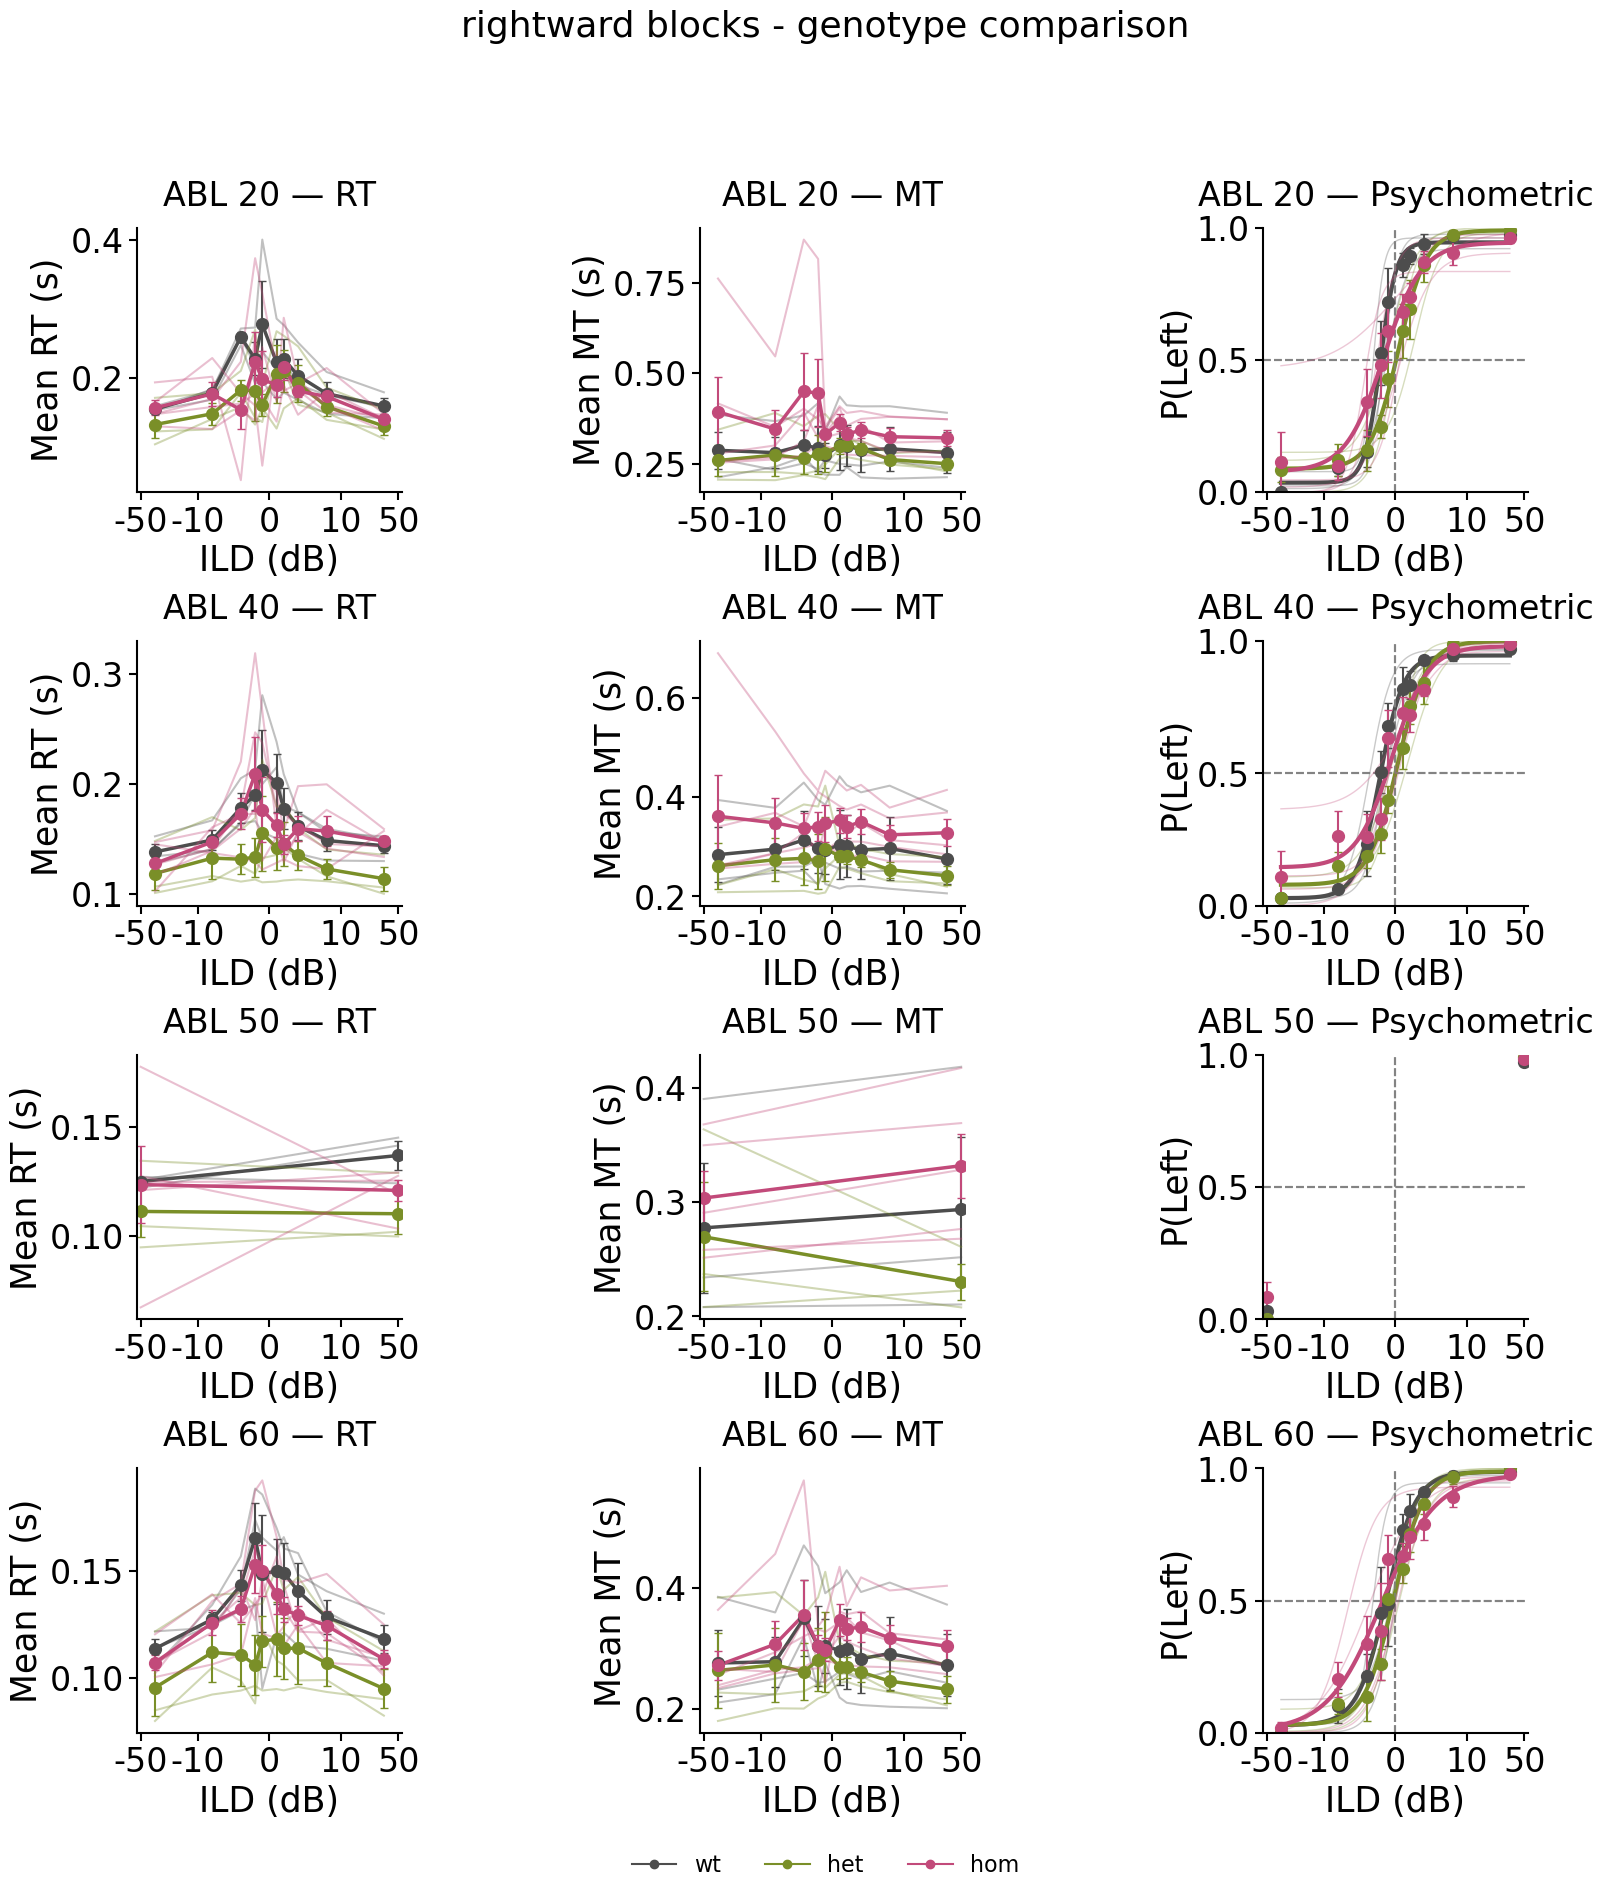

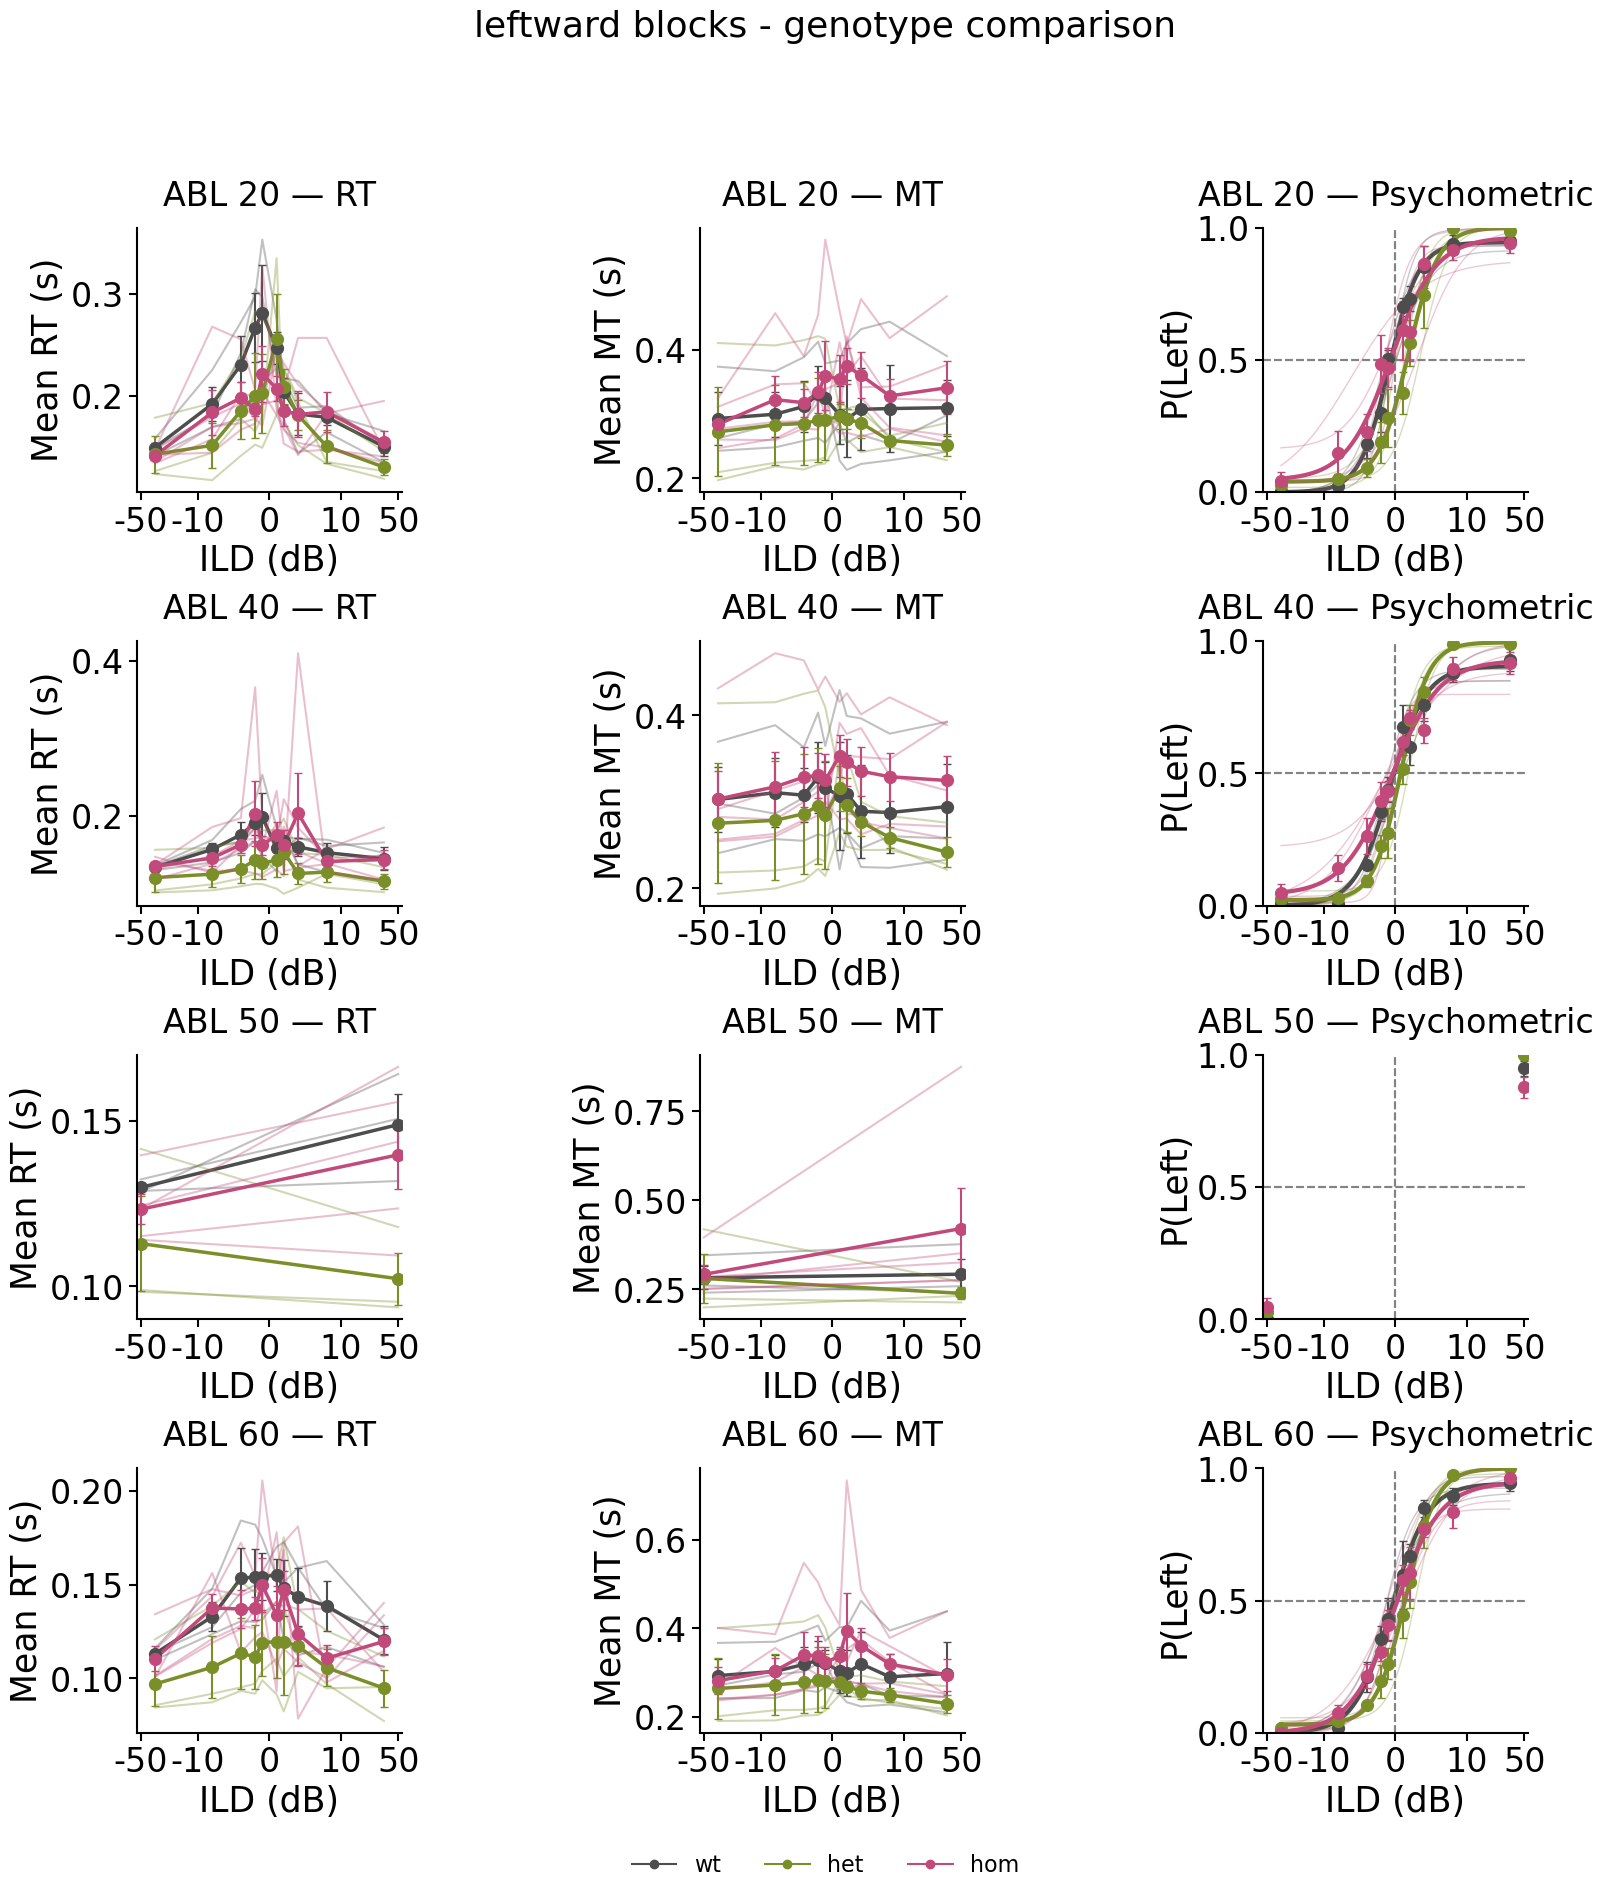

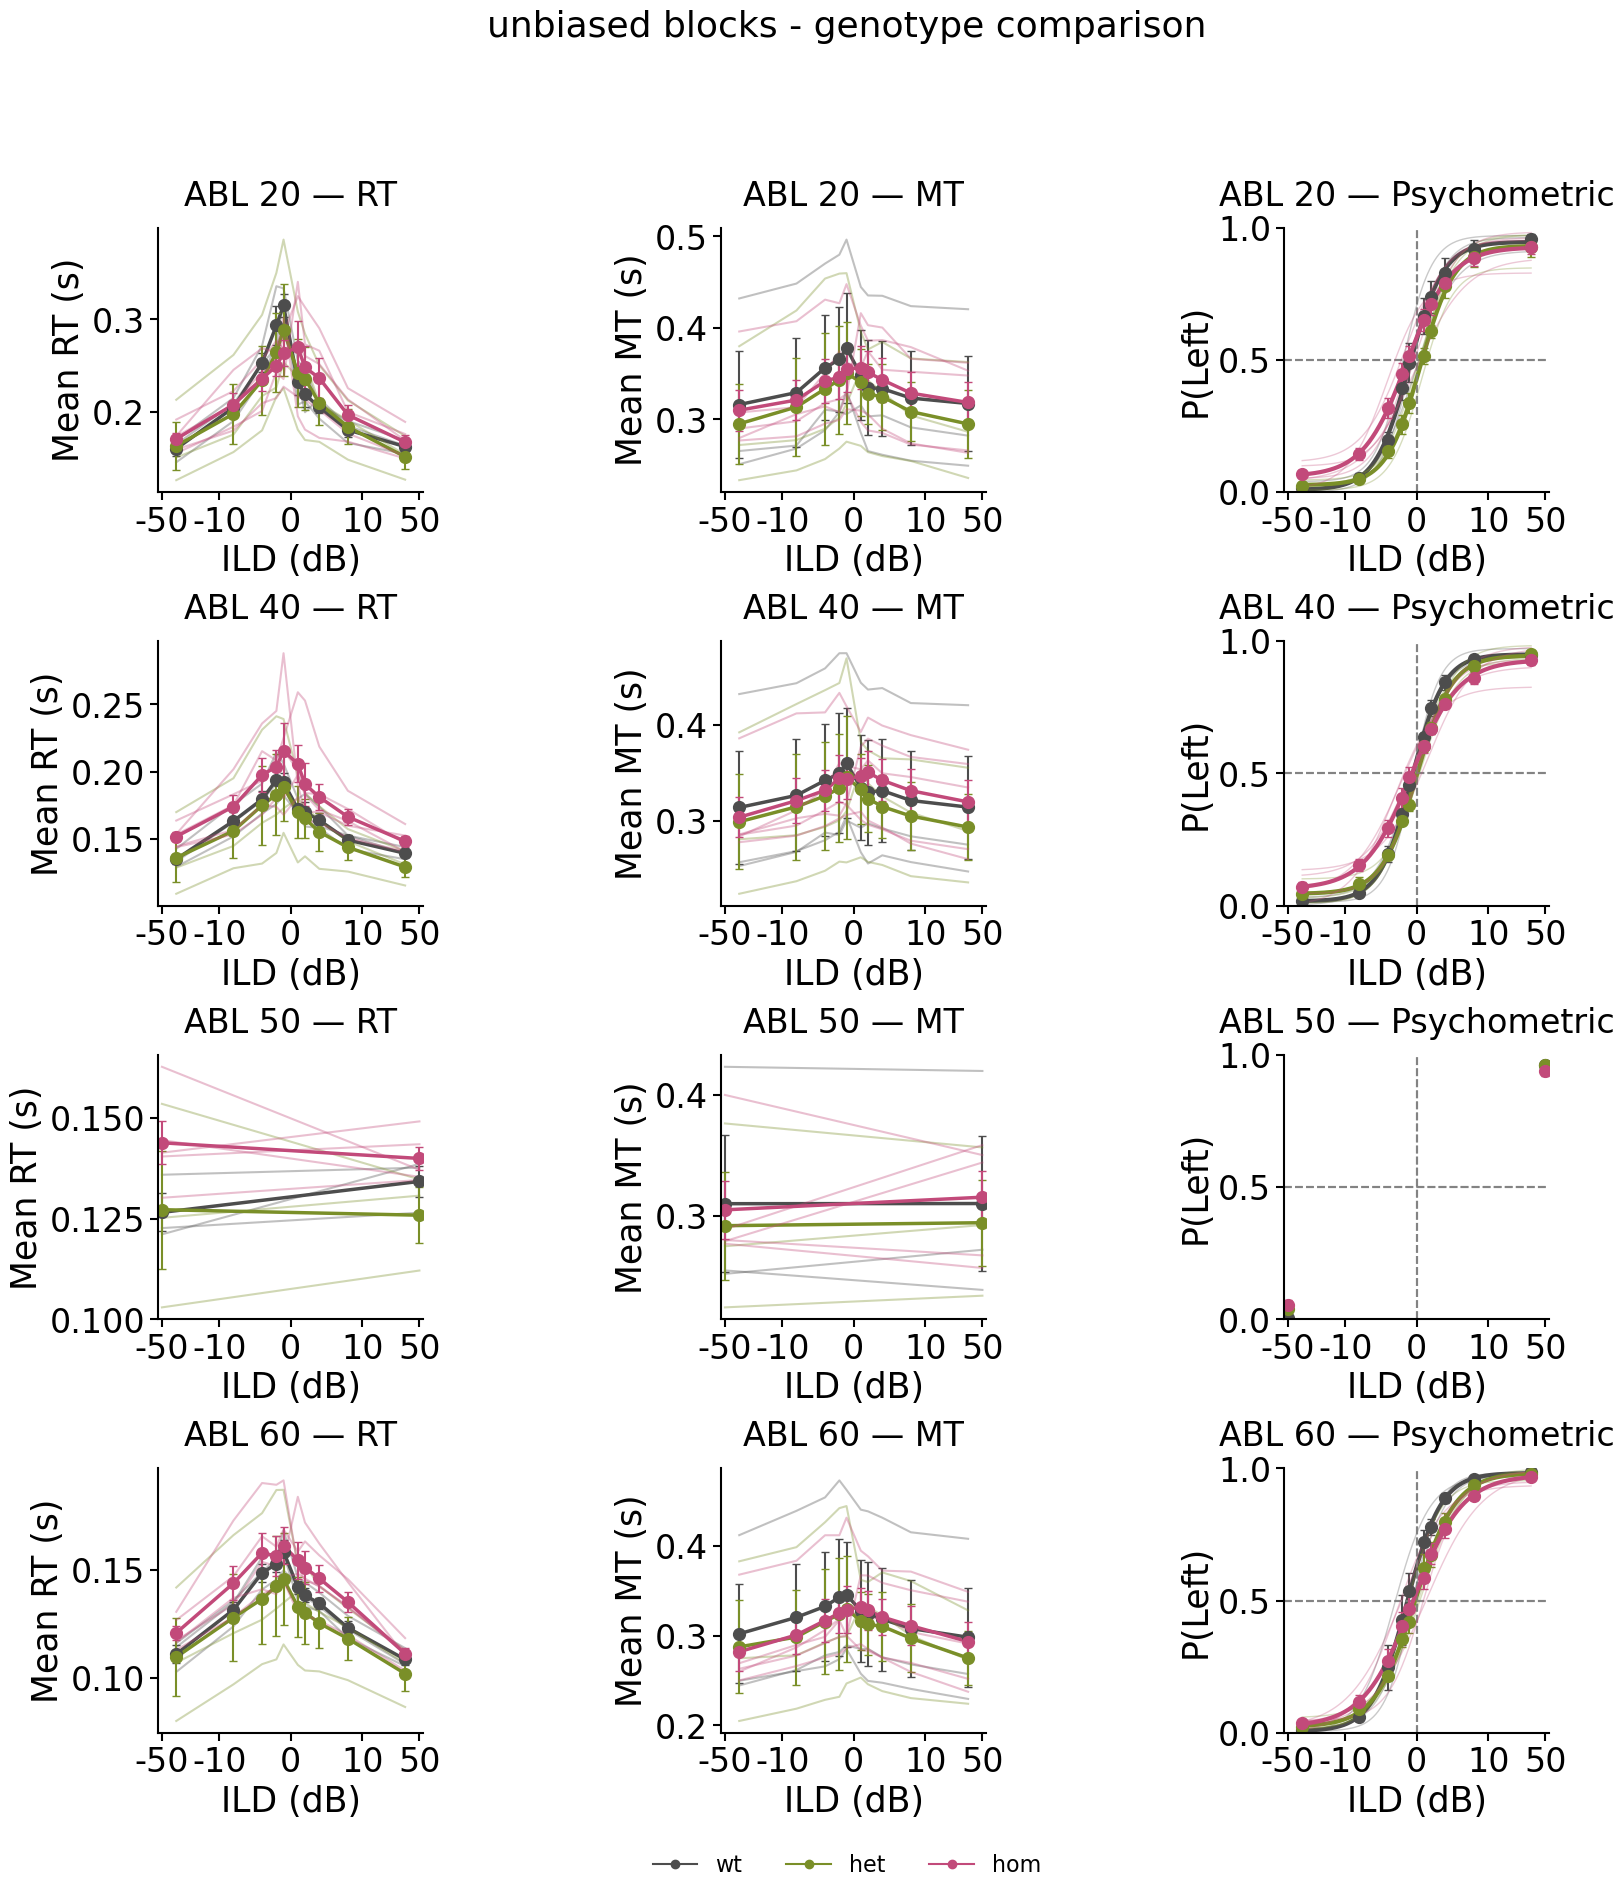

{'block_conditions': {'rightward': {'figure': <Figure size 1800x1920 with 12 Axes>,
   'prepared': {'wt': {'rt_per_subj':      animal  ABL   ILD   mean_rt
     0   ASD0040   20 -16.0  0.158289
     1   ASD0040   20  -8.0  0.181485
     2   ASD0040   20  -4.0  0.271437
     3   ASD0040   20  -2.0  0.272848
     4   ASD0040   20  -1.0  0.400945
     ..      ...  ...   ...       ...
     91  ASD0047   60   1.0  0.119773
     92  ASD0047   60   2.0  0.121082
     93  ASD0047   60   4.0  0.114888
     94  ASD0047   60   8.0  0.113507
     95  ASD0047   60  16.0  0.107906
     
     [96 rows x 4 columns],
     'rt_group':     ABL   ILD      mean       sem  n
     0    20 -16.0  0.154141  0.002089  3
     1    20  -8.0  0.177522  0.004916  3
     2    20  -4.0  0.259165  0.006978  3
     3    20  -2.0  0.227089  0.024054  3
     4    20  -1.0  0.277456  0.063028  3
     5    20   1.0  0.221956  0.034299  3
     6    20   2.0  0.227064  0.028419  3
     7    20   4.0  0.202743  0.025013  3
   

In [6]:
LAYOUT = "block_conditions"  # "block_conditions", "block_condition_params", "block_bias", "left_to_right_transition", "biased_transition_aligned", "biased_transition_collapsed", "genotype_blocks", "animal_blocks", or "all"
PLOT_VIEW = None             # set to a view name to plot just one selected group/view
PLOT_BLOCK_CONDITIONS = ["rightward", "leftward", "unbiased"]
MAX_ANIMALS = None           # e.g. 3 while testing animal_blocks
TRANSITION_BIN_SIZE = 1      # use 1 for no smoothing, or e.g. 5 to average neighboring transition trials

plot_views = [v for v in views if PLOT_VIEW is None or v.name == PLOT_VIEW]
if not plot_views:
    raise ValueError(f"PLOT_VIEW={PLOT_VIEW!r} did not match any selected view.")

out = bb.plot_biased_blocks(
    bundle=bundle,
    views=plot_views,
    layout=LAYOUT,
    view_colors=view_colors,
    view_styles=view_styles,
    block_conditions=PLOT_BLOCK_CONDITIONS,
    max_animals=MAX_ANIMALS,
    transition_bin_size=TRANSITION_BIN_SIZE,
    show=True,
)

out["figures"]

## 7. Example Recipes

### Compare genotypes within one cohort

```python
DATASET_SELECTIONS = [("SHANK3", "cohort1")]
COMPARISON = "genotypes"
SPLIT_BY = "none"
GENOTYPES = ["wt", "het", "hom"]
```

### One figure per animal

```python
LAYOUT = "animal_blocks"
MAX_ANIMALS = 3  # or None for every animal
```

### Compare genotypes for only rightward blocks

```python
LAYOUT = "block_conditions"
PLOT_BLOCK_CONDITIONS = ["rightward"]
```

### Compare psychometric parameters across genotypes and block conditions

```python
LAYOUT = "block_condition_params"
PLOT_BLOCK_CONDITIONS = ["rightward", "leftward", "unbiased"]
```

### Plot block bias summaries

```python
LAYOUT = "block_bias"
```

### Plot left-to-right transition choice traces

```python
LAYOUT = "left_to_right_transition"
```

### Test aligned biased-to-biased transitions

```python
LAYOUT = "biased_transition_aligned"
```

### Test fully collapsed biased-to-biased transitions

```python
LAYOUT = "biased_transition_collapsed"
```

### One selected genotype/view only

```python
PLOT_VIEW = "hom"
LAYOUT = "genotype_blocks"
```

## 8. Block History Exploration

These figures are kept separate from `LAYOUT` on purpose, so you can explore previous/current block effects without changing the main plotting workflow.

wt {'performance_figure': 'ok', 'phase_figure': 'ok', 'psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'diagnostic_psychometric_figures': ['R->L_ABL_20', 'U->L_ABL_20', 'U->L_ABL_40', 'U->R_ABL_20', 'U->R_ABL_40', 'U->R_ABL_60'], 'current_performance_figure': 'ok', 'current_phase_figure': 'ok', 'current_psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'current_diagnostic_psychometric_figures': ['leftward_ABL_20']}


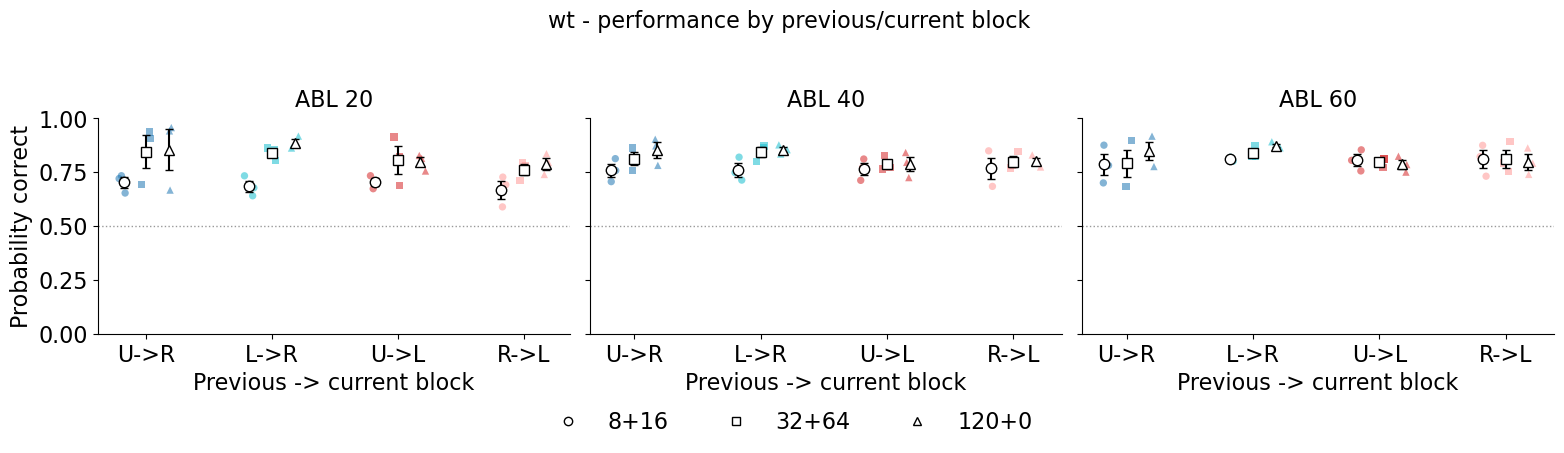

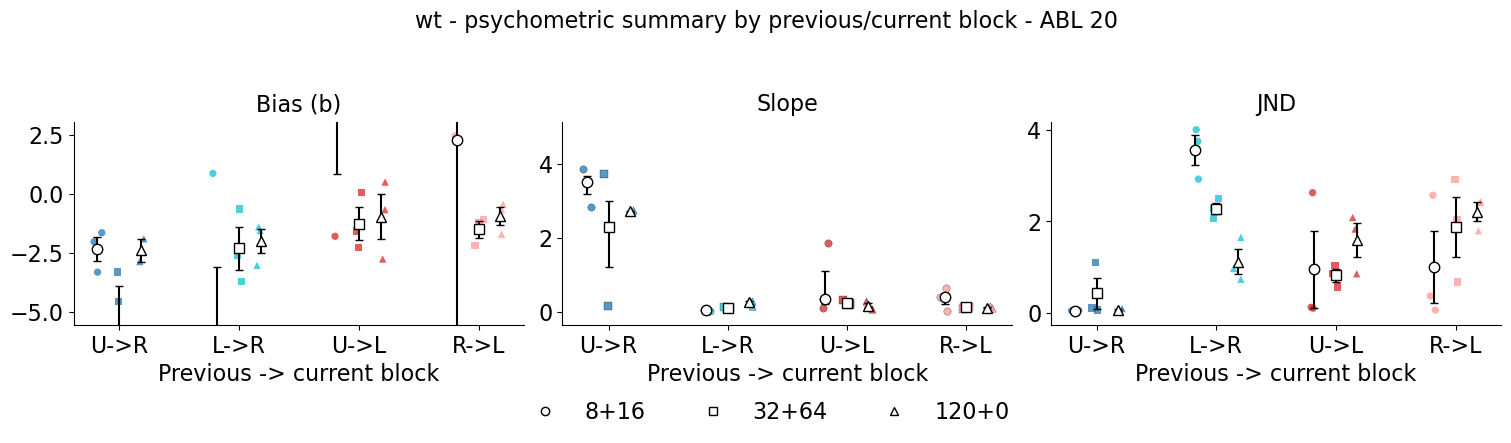

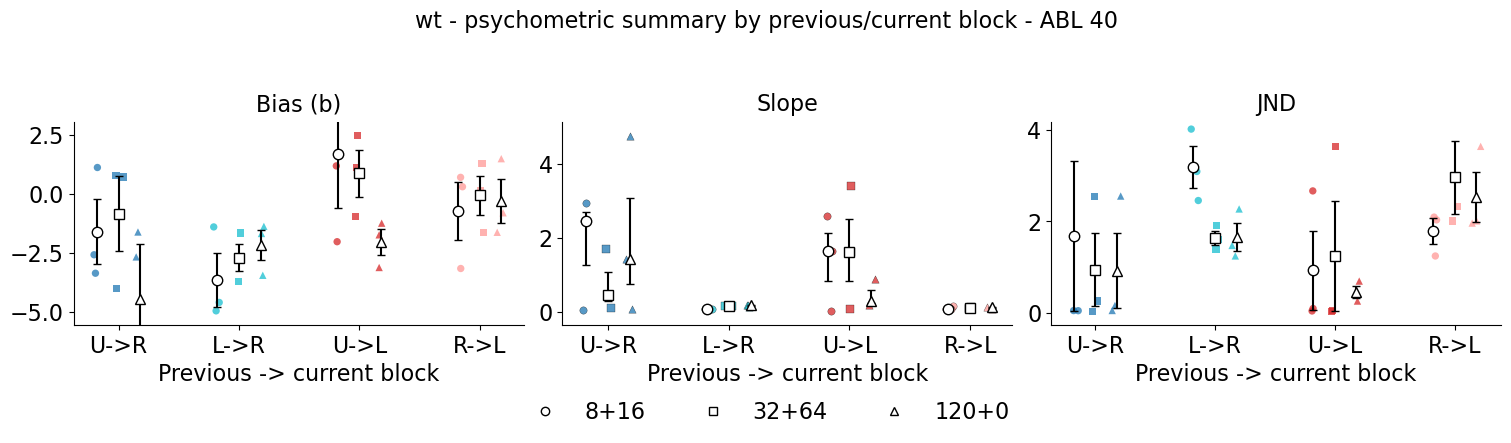

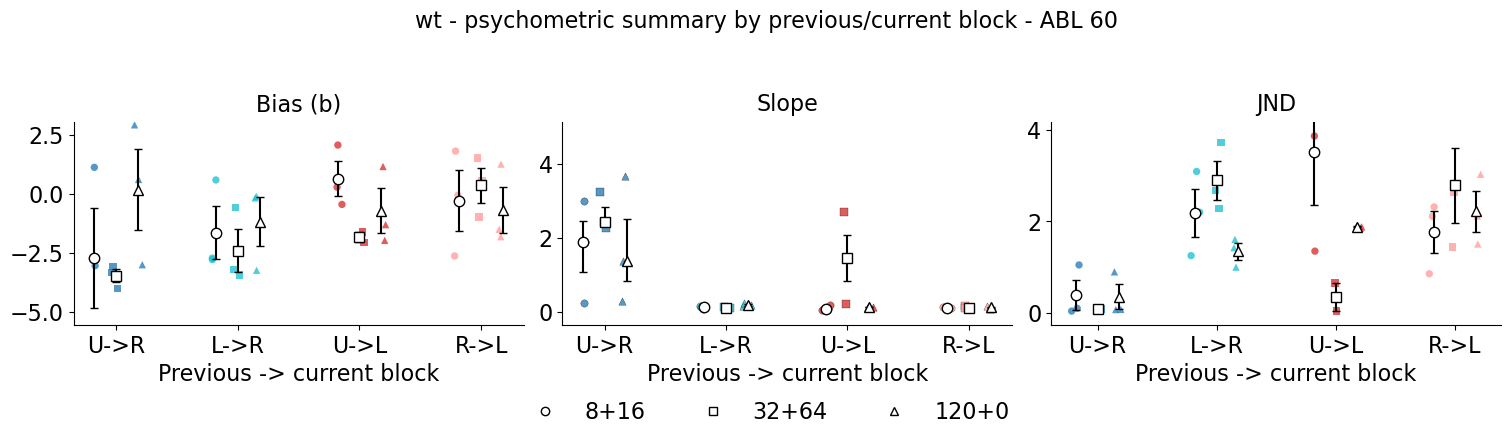

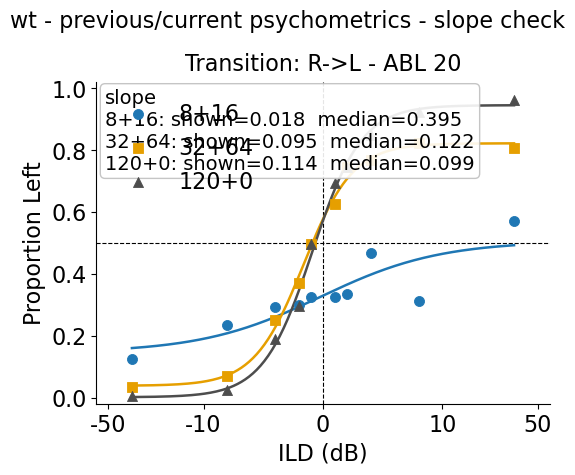

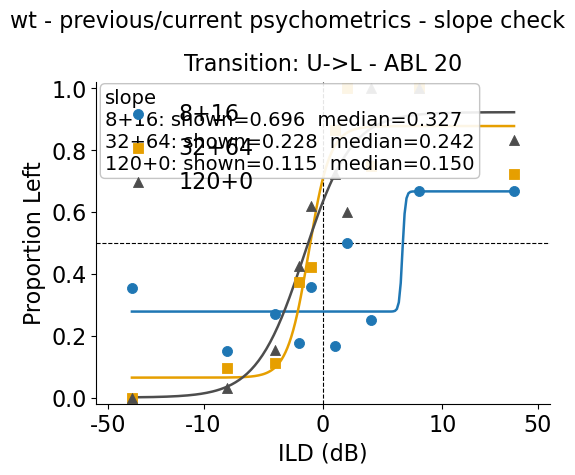

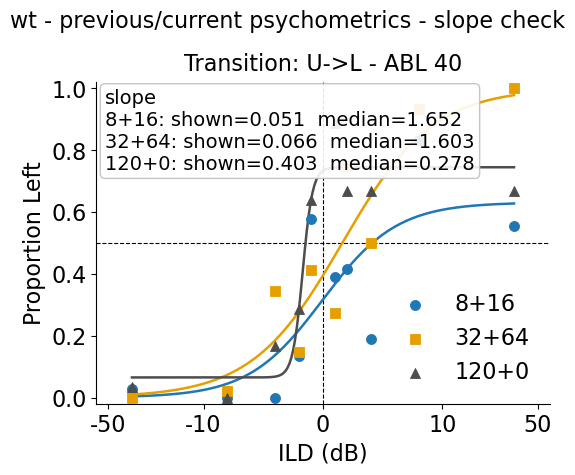

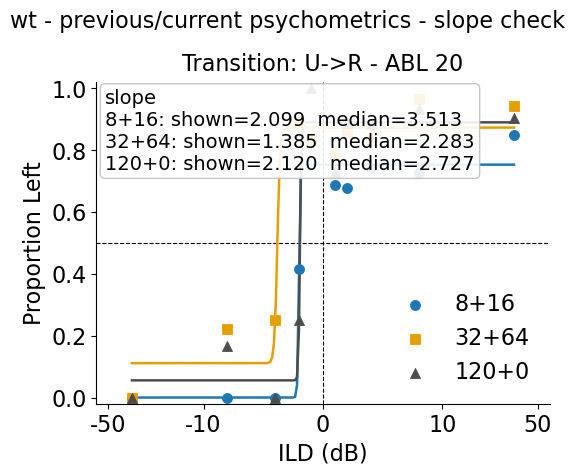

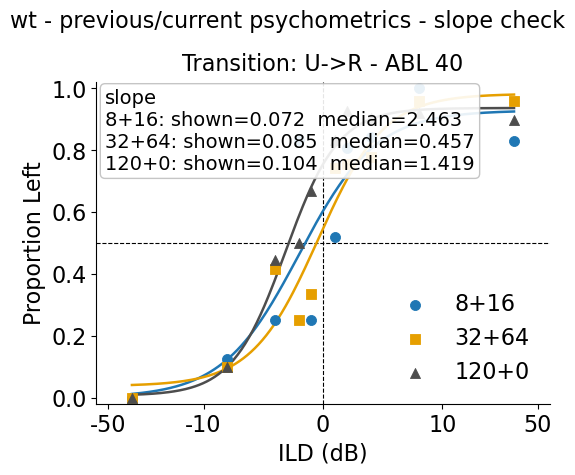

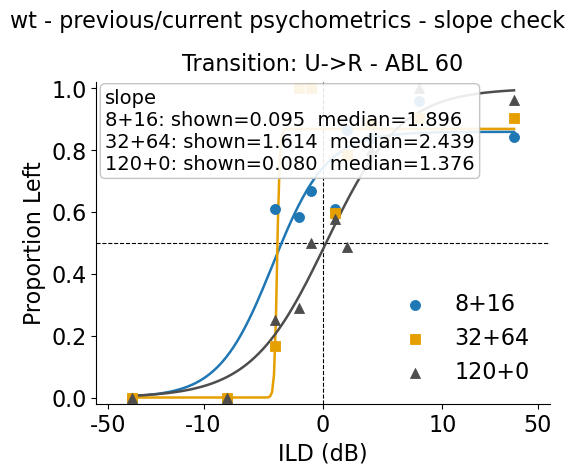

Previous/current suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,transition_type,R->L,20,8+16,effective_slope,0.395160,median,3,<NA>
1,transition_type,R->L,20,8+16,displayed_curve_slope,0.018039,displayed_curve,<NA>,<NA>
2,transition_type,R->L,20,32+64,effective_slope,0.121505,median,3,<NA>
3,transition_type,R->L,20,32+64,displayed_curve_slope,0.094788,displayed_curve,<NA>,<NA>
4,transition_type,R->L,20,120+0,effective_slope,0.099287,median,3,<NA>
5,transition_type,R->L,20,120+0,displayed_curve_slope,0.114484,displayed_curve,<NA>,<NA>
6,transition_type,U->L,20,8+16,effective_slope,0.326853,median,3,<NA>
7,transition_type,U->L,20,8+16,displayed_curve_slope,0.696317,displayed_curve,<NA>,<NA>
8,transition_type,U->L,20,32+64,effective_slope,0.241764,median,3,<NA>
9,transition_type,U->L,20,32+64,displayed_curve_slope,0.227907,displayed_curve,<NA>,<NA>


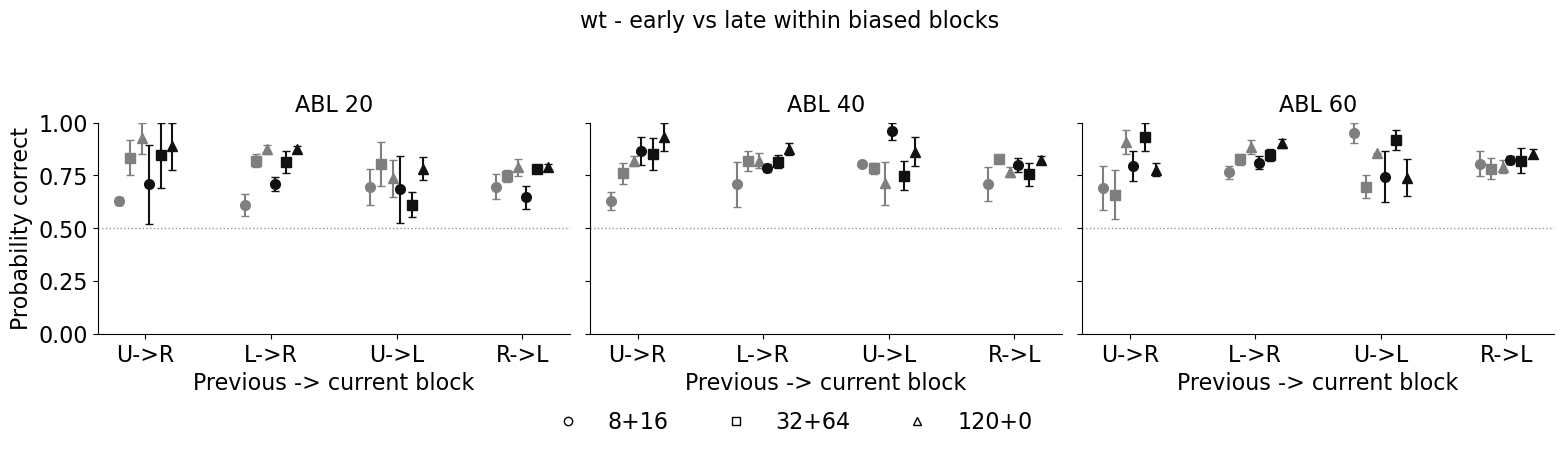

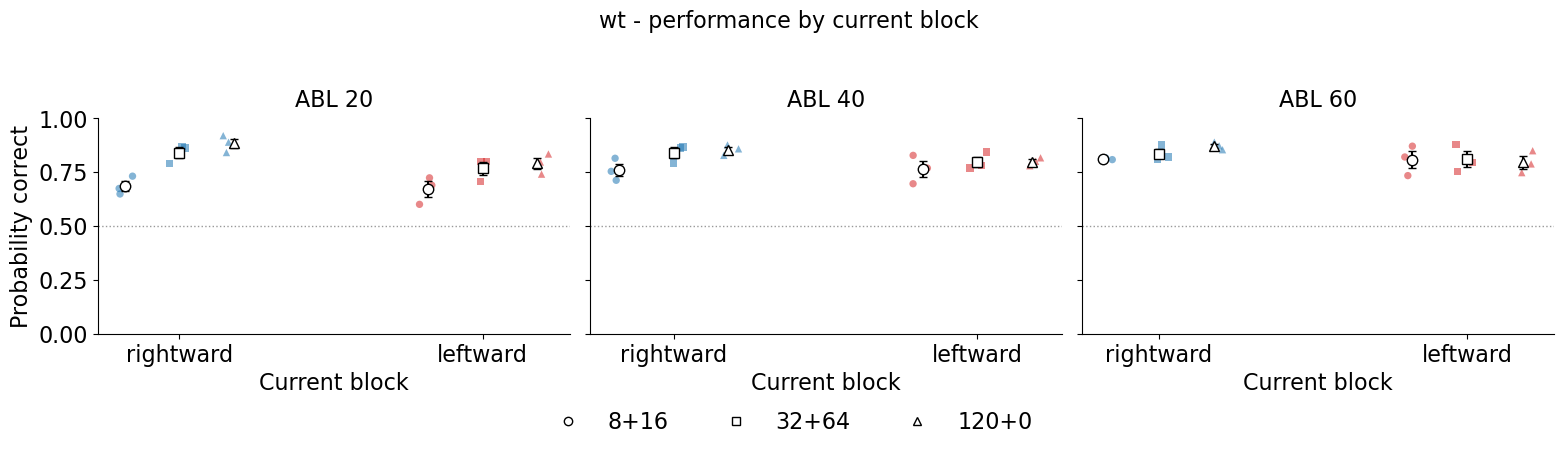

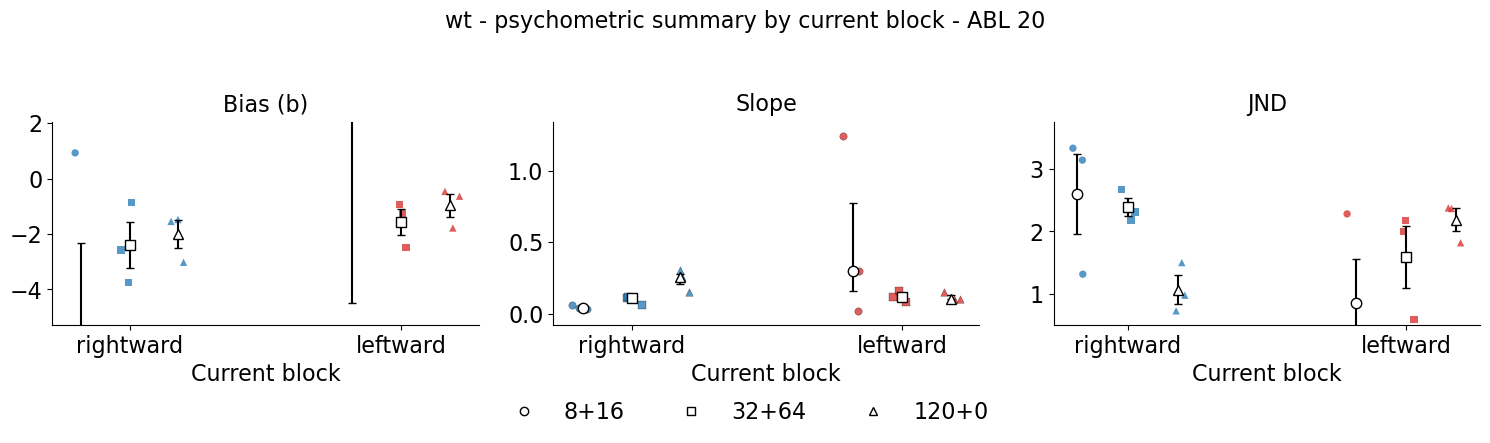

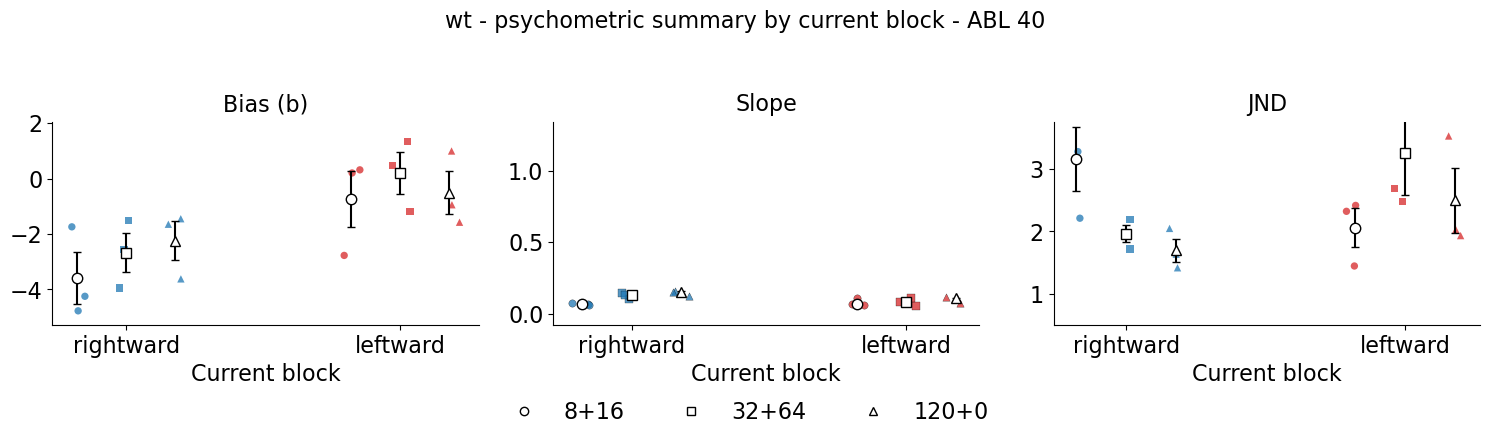

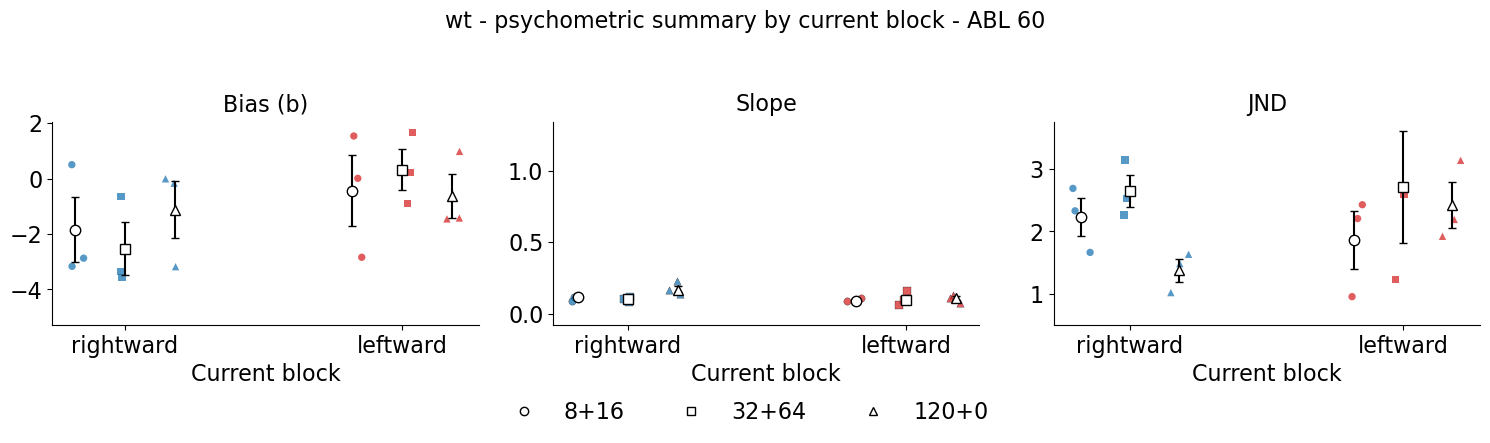

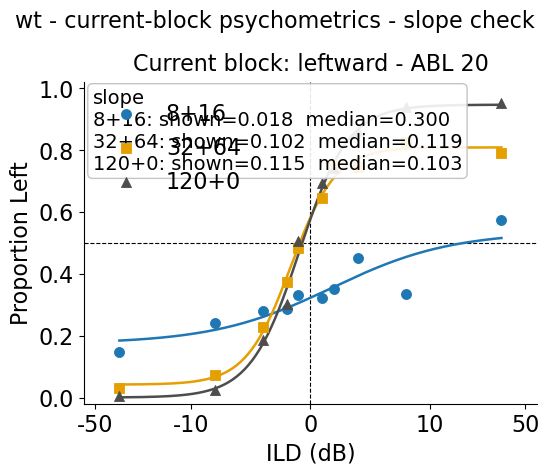

Current-block suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,current_block_condition,leftward,20,8+16,effective_slope,0.300128,median,3,<NA>
1,current_block_condition,leftward,20,8+16,displayed_curve_slope,0.018066,displayed_curve,<NA>,<NA>
2,current_block_condition,leftward,20,32+64,effective_slope,0.118781,median,3,<NA>
3,current_block_condition,leftward,20,32+64,displayed_curve_slope,0.102046,displayed_curve,<NA>,<NA>
4,current_block_condition,leftward,20,120+0,effective_slope,0.103312,median,3,<NA>
5,current_block_condition,leftward,20,120+0,displayed_curve_slope,0.115193,displayed_curve,<NA>,<NA>


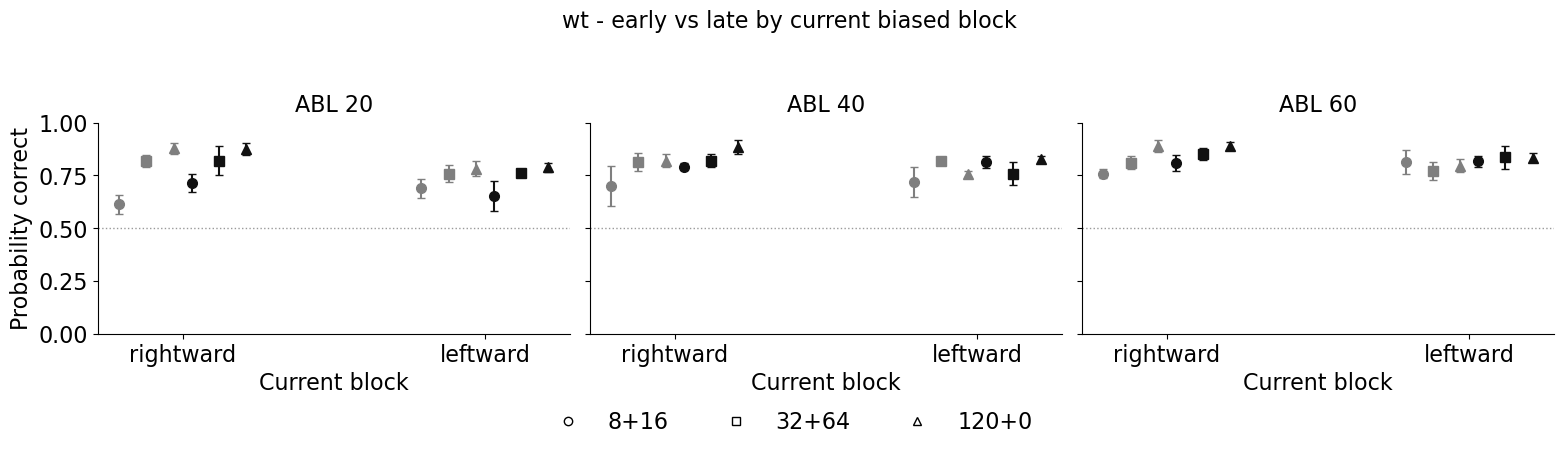

het {'performance_figure': 'ok', 'phase_figure': 'ok', 'psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'diagnostic_psychometric_figures': ['U->L_ABL_20', 'U->L_ABL_60', 'U->R_ABL_20', 'U->R_ABL_40', 'U->R_ABL_60'], 'current_performance_figure': 'ok', 'current_phase_figure': 'ok', 'current_psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'current_diagnostic_psychometric_figures': ['rightward_ABL_20']}


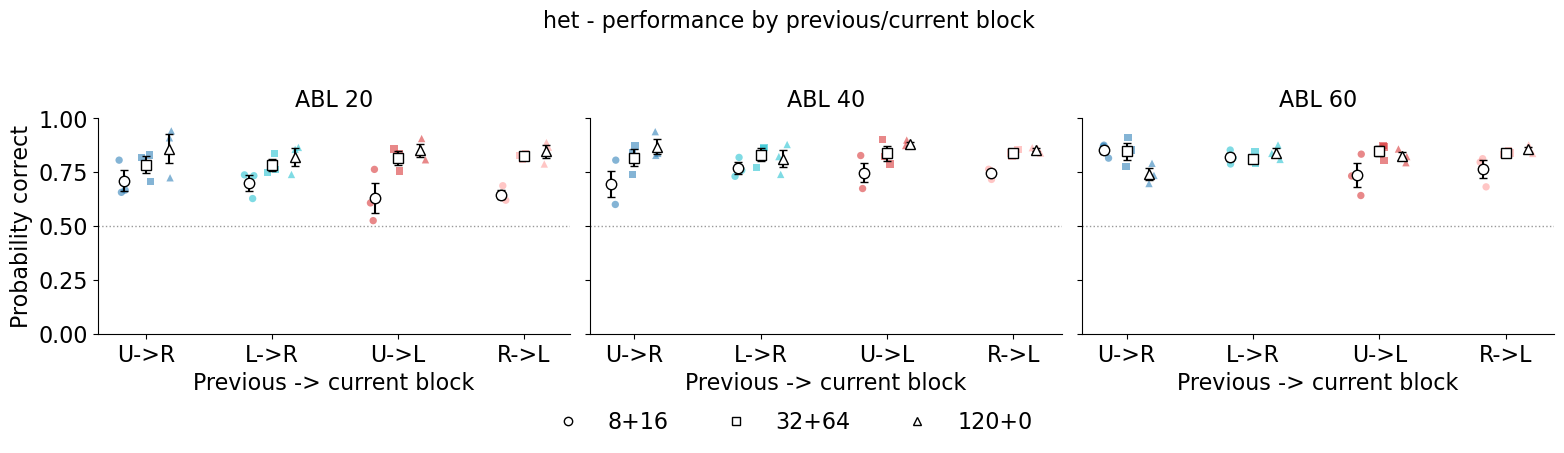

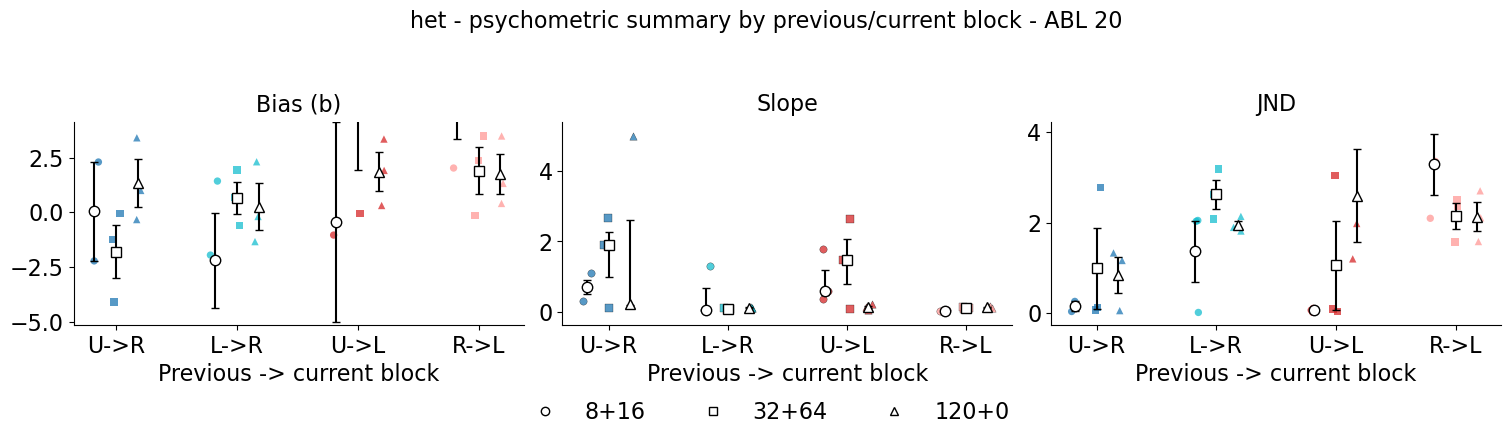

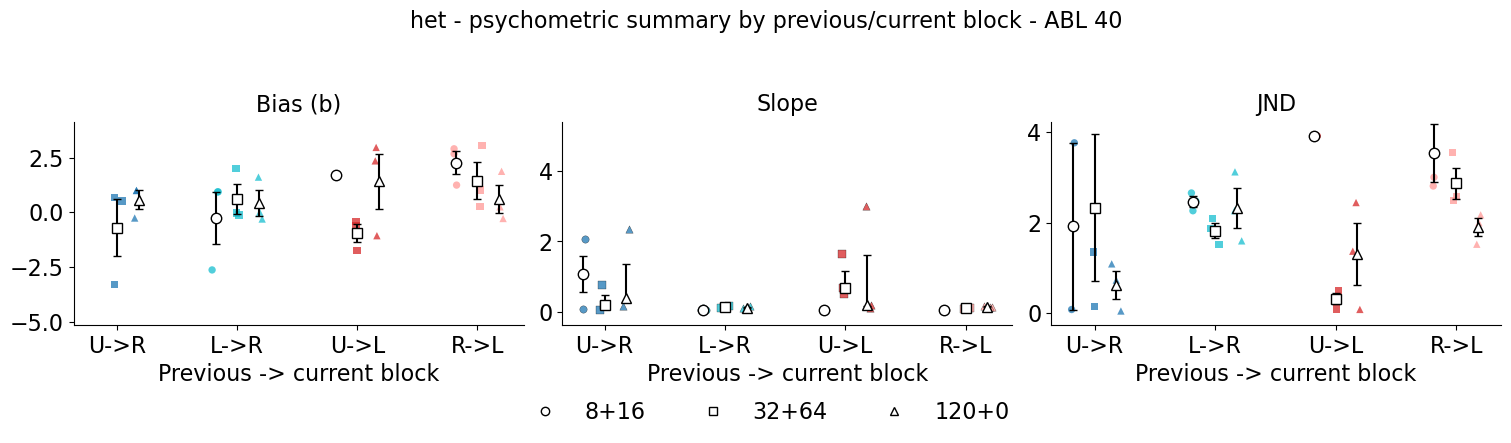

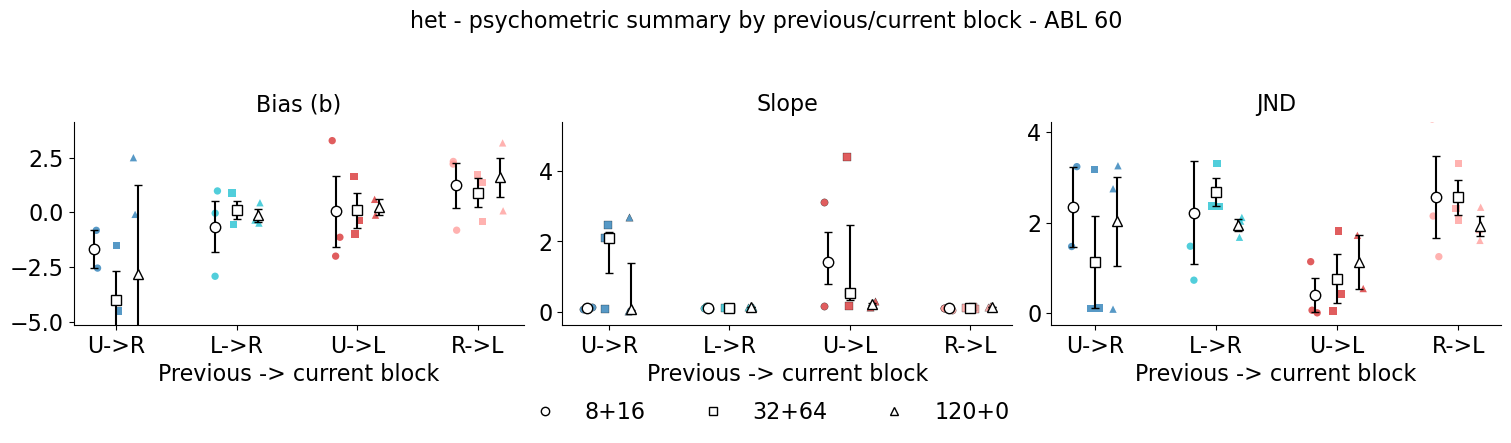

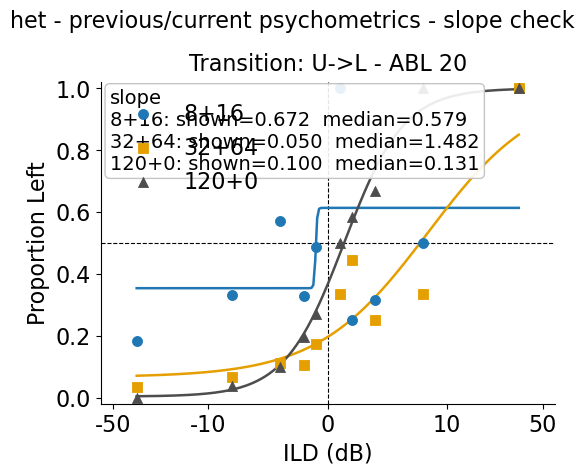

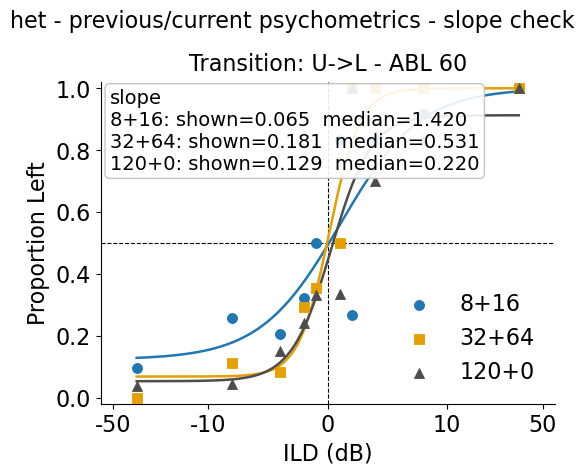

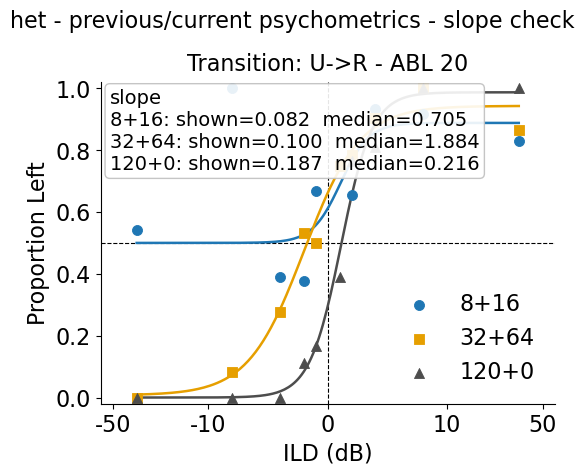

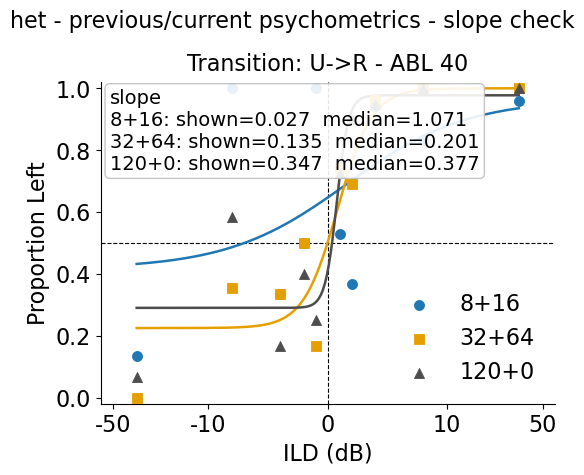

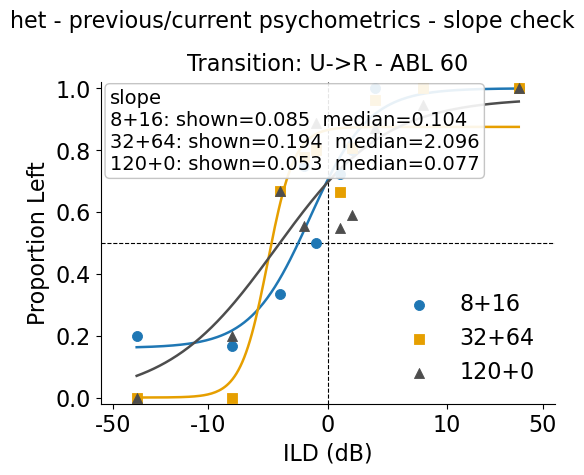

Previous/current suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,transition_type,U->L,20,8+16,effective_slope,0.579127,median,3,<NA>
1,transition_type,U->L,20,8+16,displayed_curve_slope,0.671832,displayed_curve,<NA>,<NA>
2,transition_type,U->L,20,32+64,effective_slope,1.481696,median,3,<NA>
3,transition_type,U->L,20,32+64,displayed_curve_slope,0.049581,displayed_curve,<NA>,<NA>
4,transition_type,U->L,20,120+0,effective_slope,0.130985,median,3,<NA>
5,transition_type,U->L,20,120+0,displayed_curve_slope,0.099999,displayed_curve,<NA>,<NA>
6,transition_type,U->L,60,8+16,effective_slope,1.420399,median,3,<NA>
7,transition_type,U->L,60,8+16,displayed_curve_slope,0.065409,displayed_curve,<NA>,<NA>
8,transition_type,U->L,60,32+64,effective_slope,0.530769,median,3,<NA>
9,transition_type,U->L,60,32+64,displayed_curve_slope,0.180843,displayed_curve,<NA>,<NA>


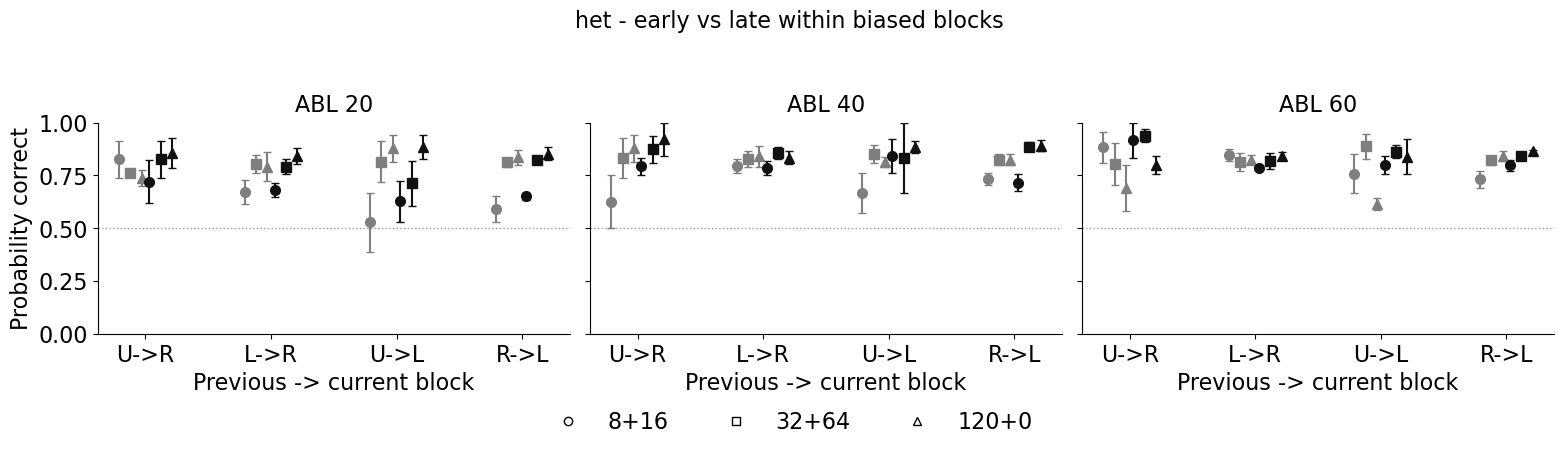

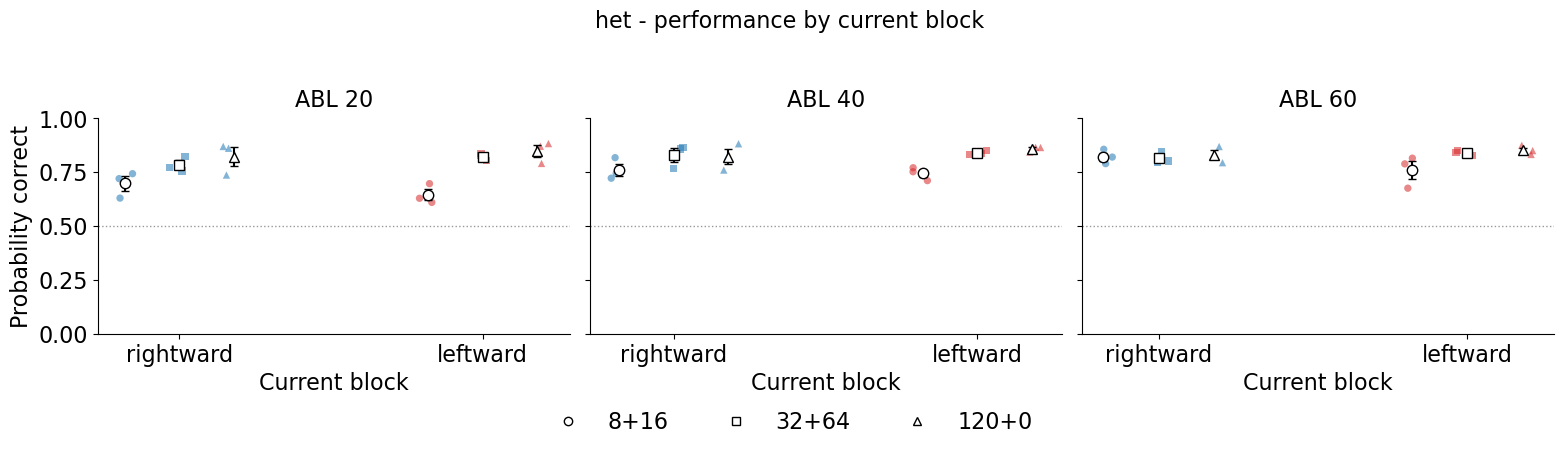

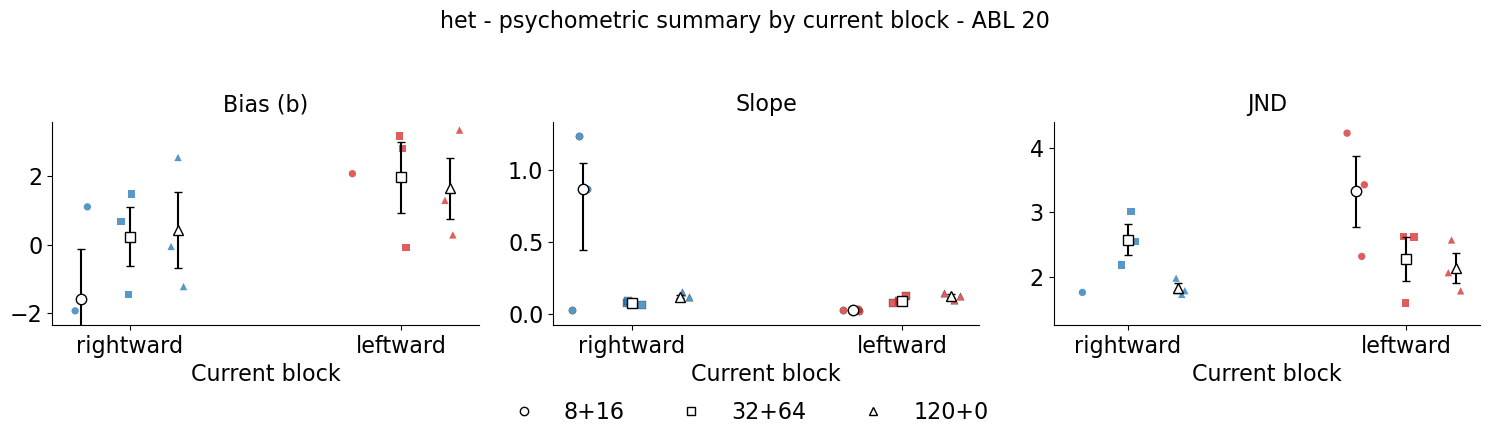

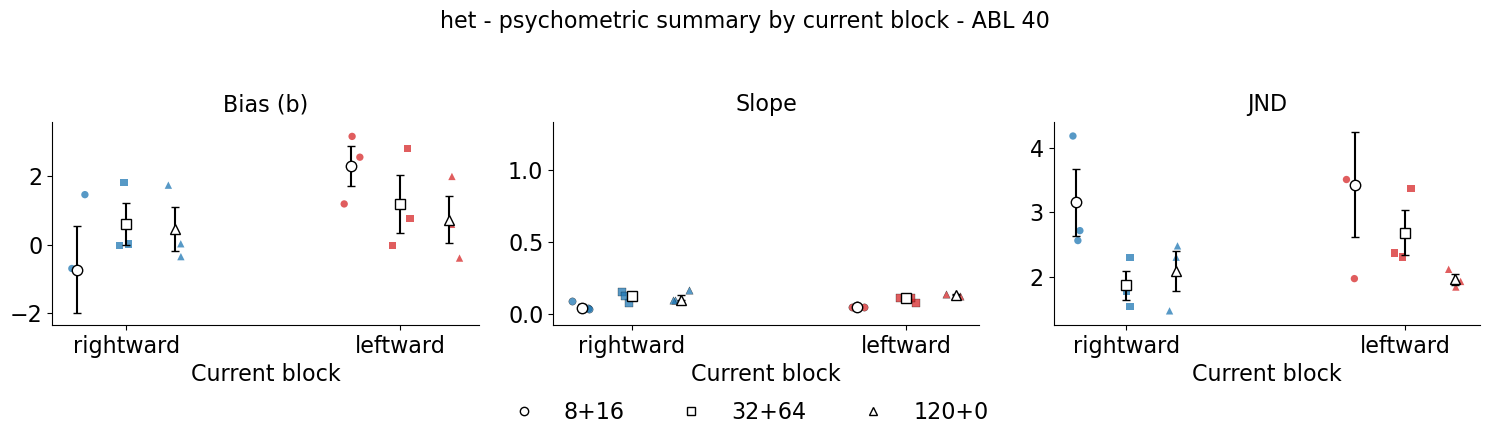

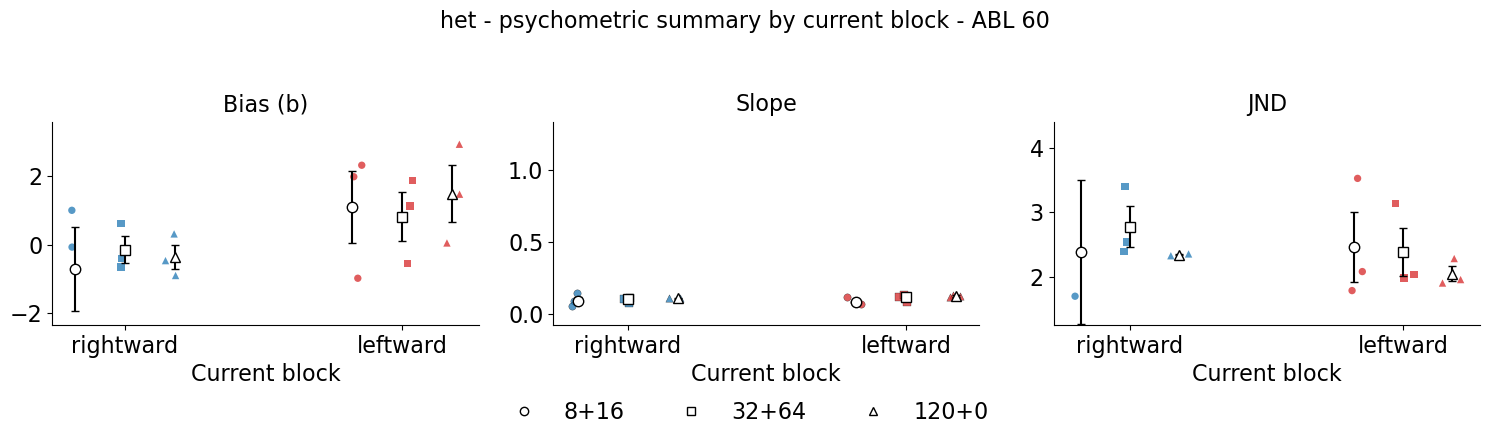

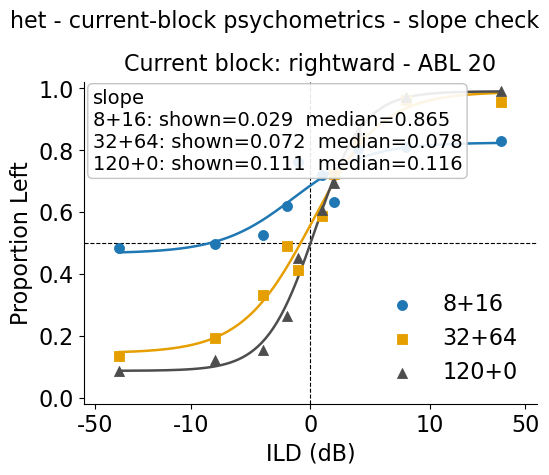

Current-block suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,current_block_condition,rightward,20,8+16,effective_slope,0.864815,median,3,<NA>
1,current_block_condition,rightward,20,8+16,displayed_curve_slope,0.029129,displayed_curve,<NA>,<NA>
2,current_block_condition,rightward,20,32+64,effective_slope,0.077539,median,3,<NA>
3,current_block_condition,rightward,20,32+64,displayed_curve_slope,0.072058,displayed_curve,<NA>,<NA>
4,current_block_condition,rightward,20,120+0,effective_slope,0.116390,median,3,<NA>
5,current_block_condition,rightward,20,120+0,displayed_curve_slope,0.111461,displayed_curve,<NA>,<NA>


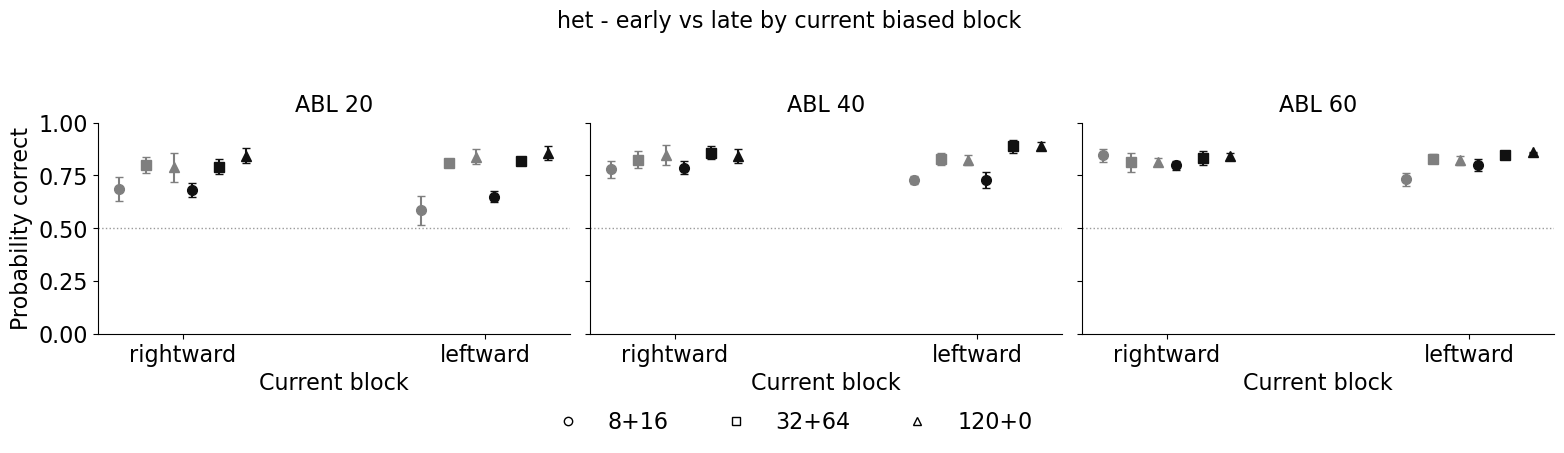

hom {'performance_figure': 'ok', 'phase_figure': 'ok', 'psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'diagnostic_psychometric_figures': ['L->R_ABL_60', 'R->L_ABL_60', 'U->L_ABL_20', 'U->L_ABL_40', 'U->L_ABL_60', 'U->R_ABL_20', 'U->R_ABL_40', 'U->R_ABL_60'], 'current_performance_figure': 'ok', 'current_phase_figure': 'ok', 'current_psy_param_figures': ['ABL_20', 'ABL_40', 'ABL_60'], 'current_diagnostic_psychometric_figures': ['leftward_ABL_20']}


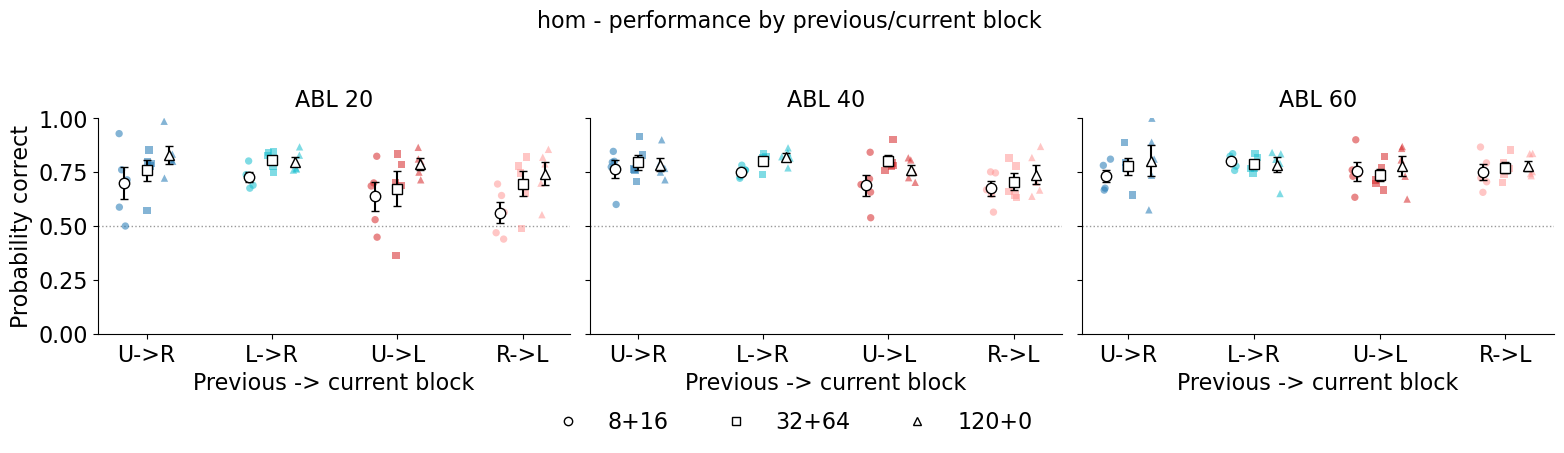

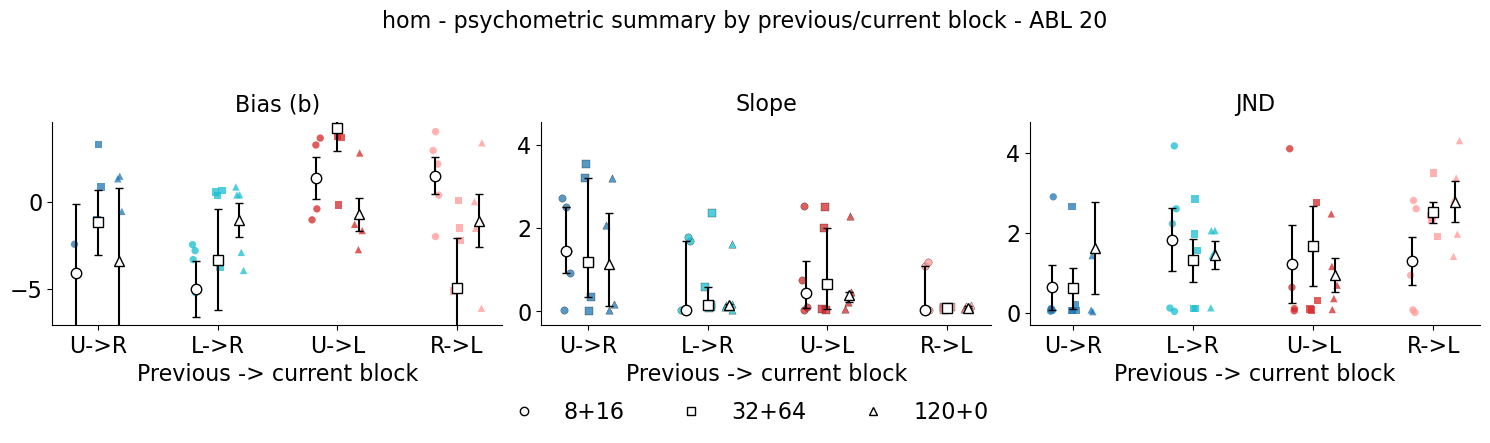

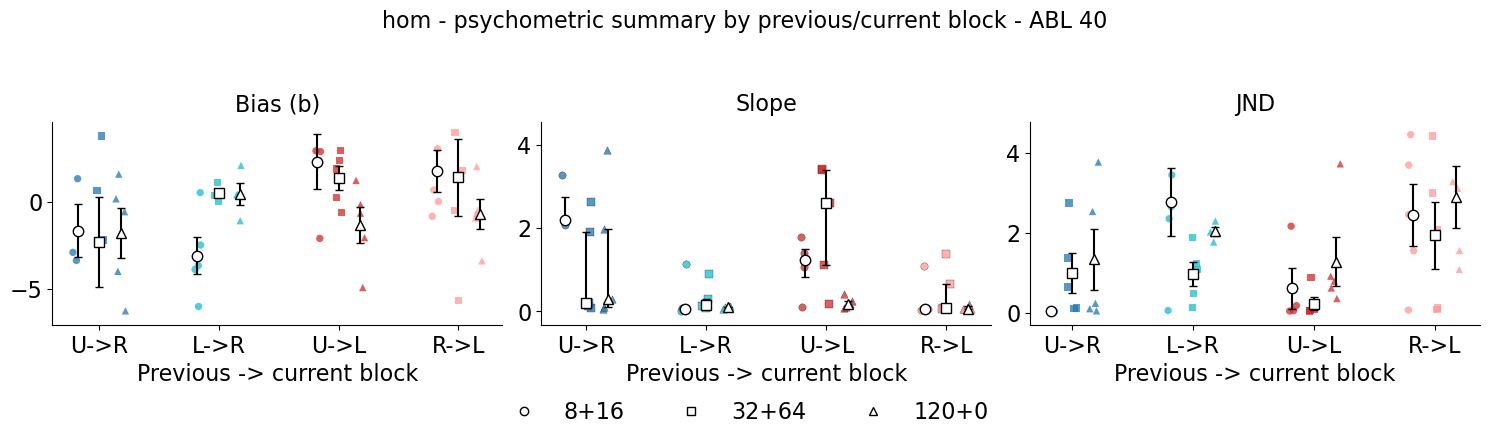

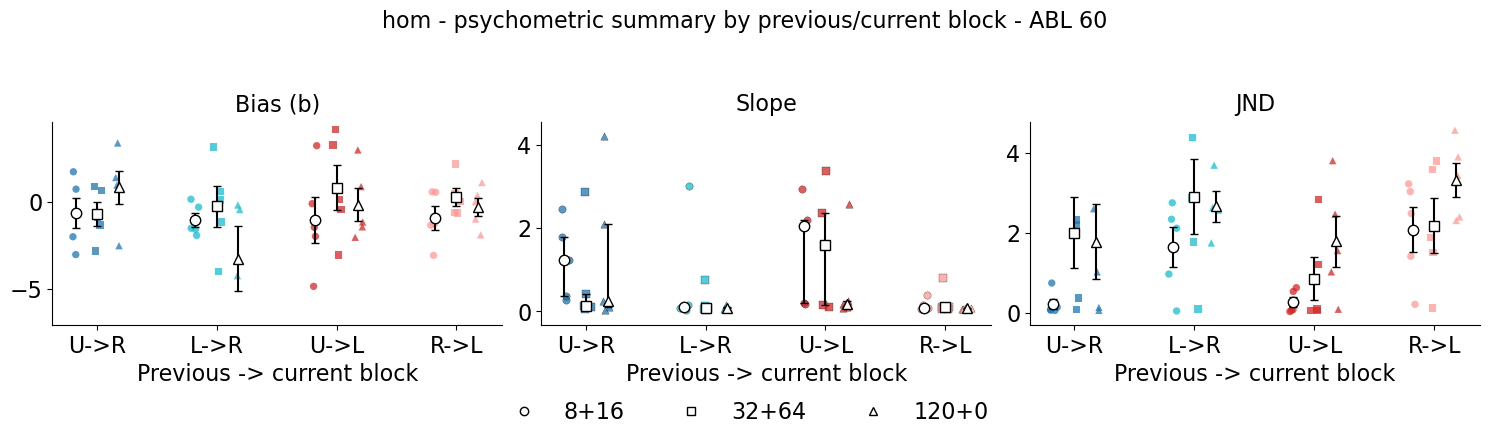

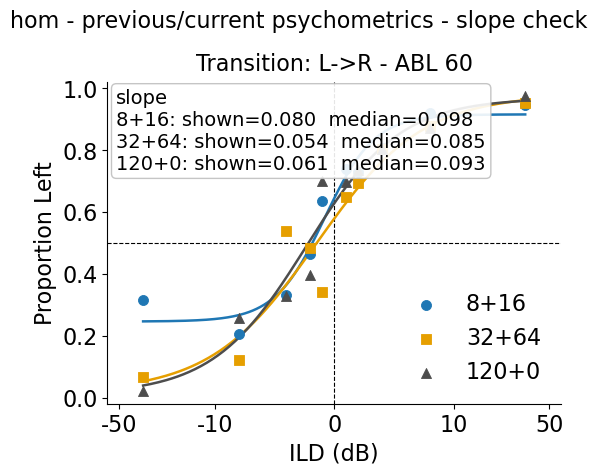

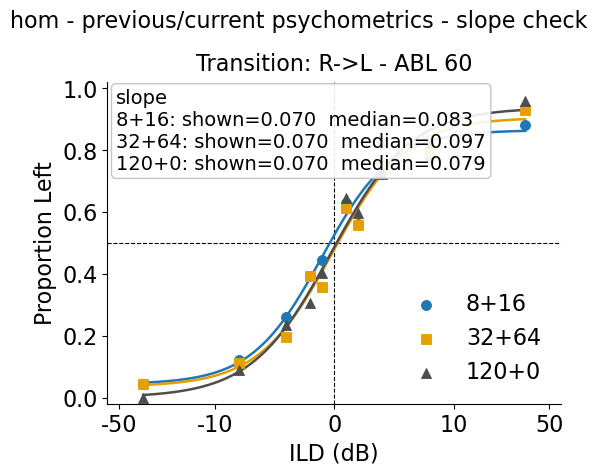

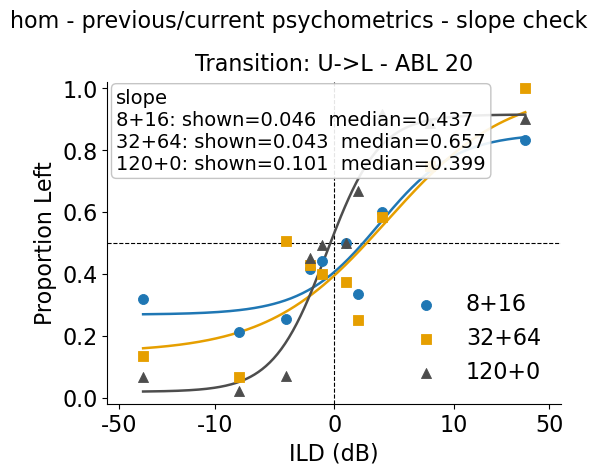

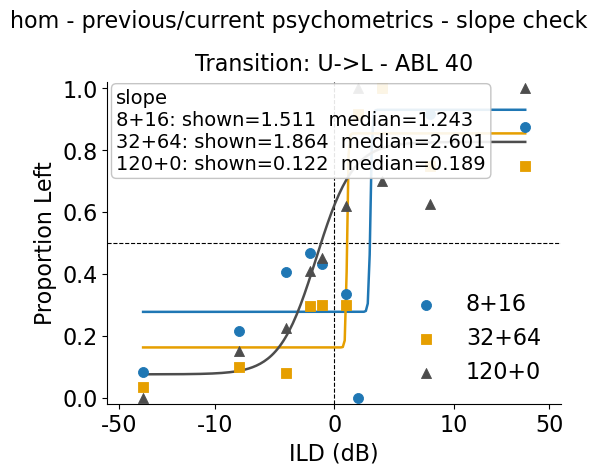

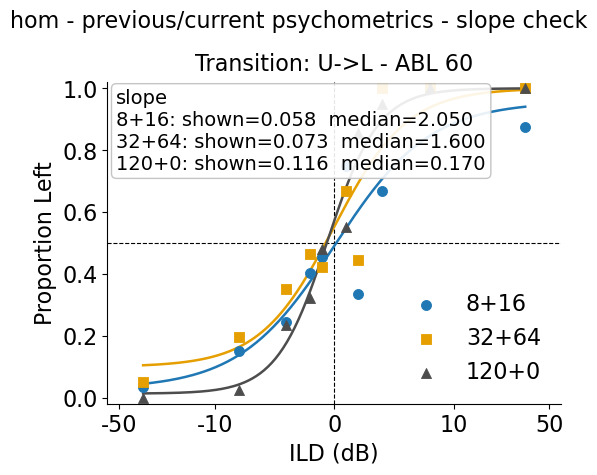

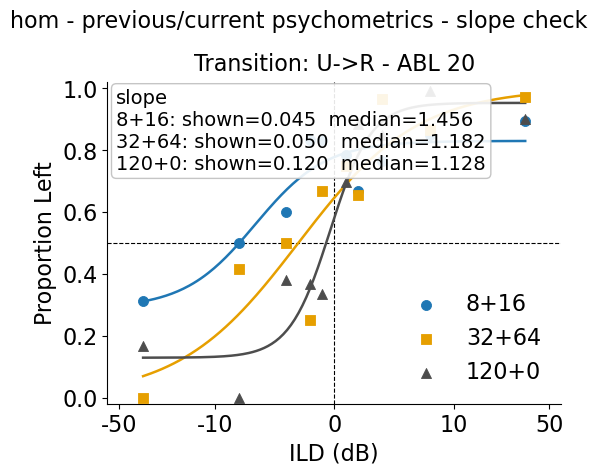

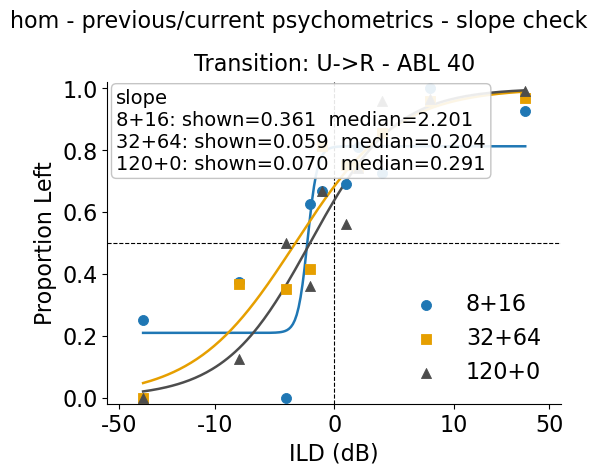

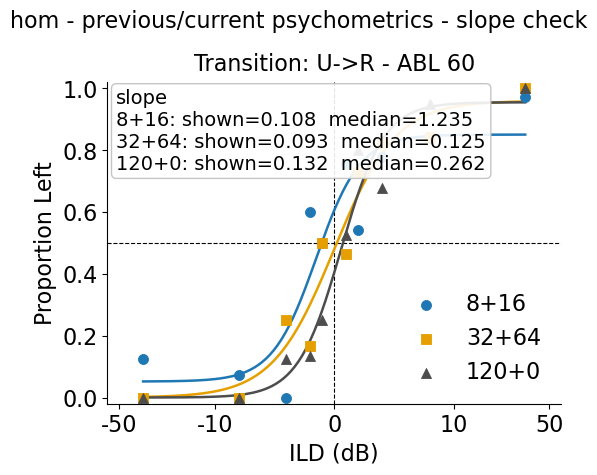

Previous/current suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,transition_type,L->R,60,8+16,effective_slope,0.098161,median,5,<NA>
1,transition_type,L->R,60,8+16,displayed_curve_slope,0.080132,displayed_curve,<NA>,<NA>
2,transition_type,L->R,60,32+64,effective_slope,0.085309,median,5,<NA>
3,transition_type,L->R,60,32+64,displayed_curve_slope,0.054243,displayed_curve,<NA>,<NA>
4,transition_type,L->R,60,120+0,effective_slope,0.092855,median,4,<NA>
5,transition_type,L->R,60,120+0,displayed_curve_slope,0.061041,displayed_curve,<NA>,<NA>
6,transition_type,R->L,60,8+16,effective_slope,0.083073,median,5,<NA>
7,transition_type,R->L,60,8+16,displayed_curve_slope,0.069780,displayed_curve,<NA>,<NA>
8,transition_type,R->L,60,32+64,effective_slope,0.096811,median,5,<NA>
9,transition_type,R->L,60,32+64,displayed_curve_slope,0.069876,displayed_curve,<NA>,<NA>


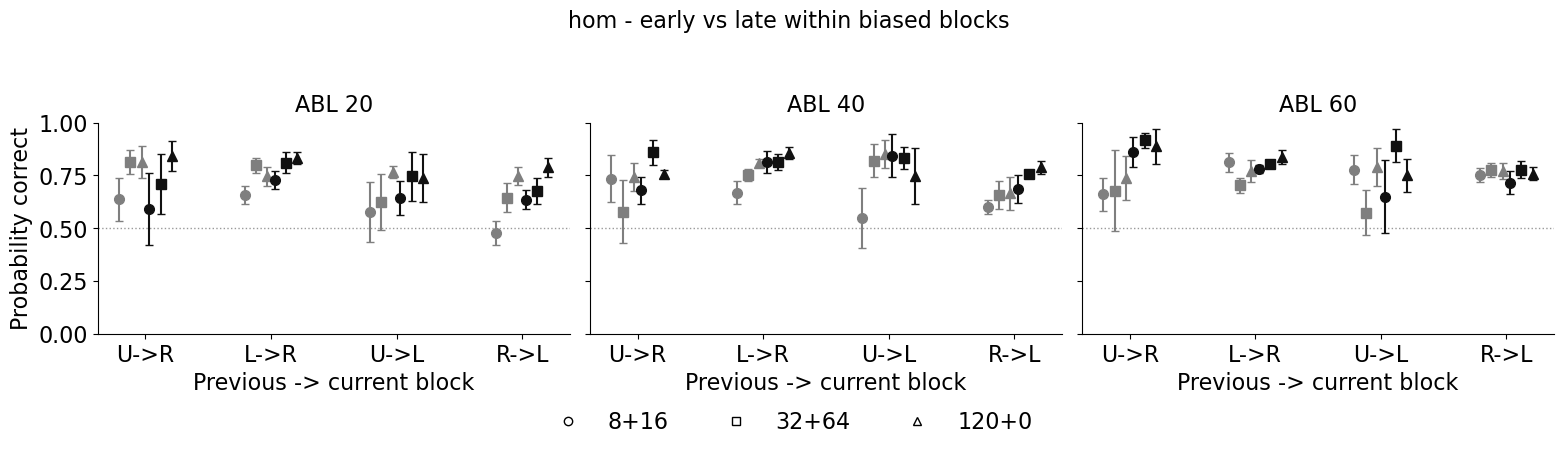

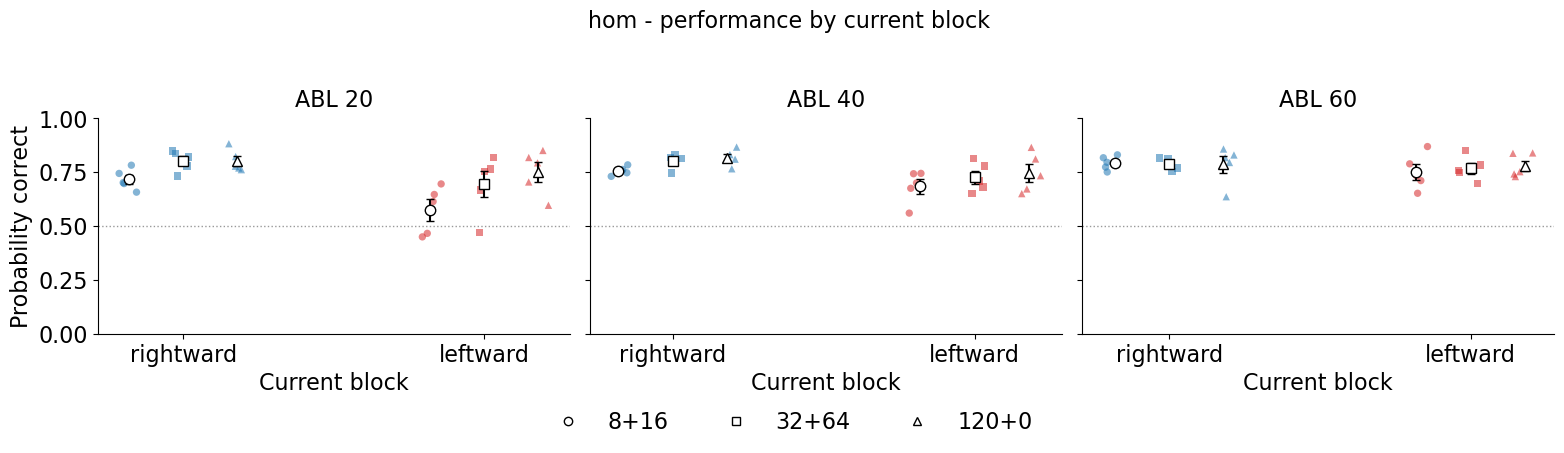

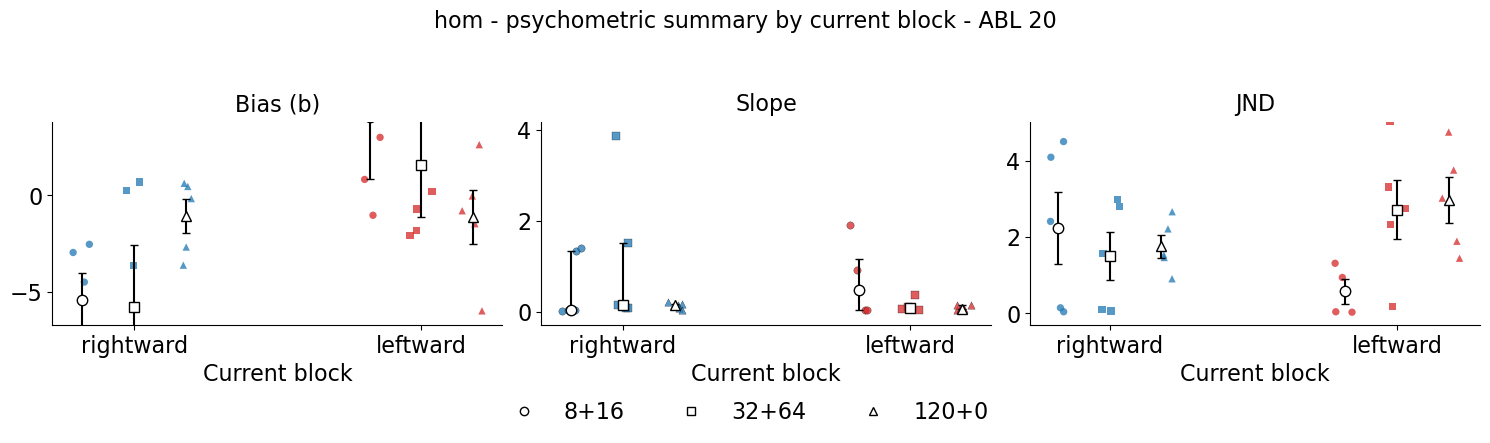

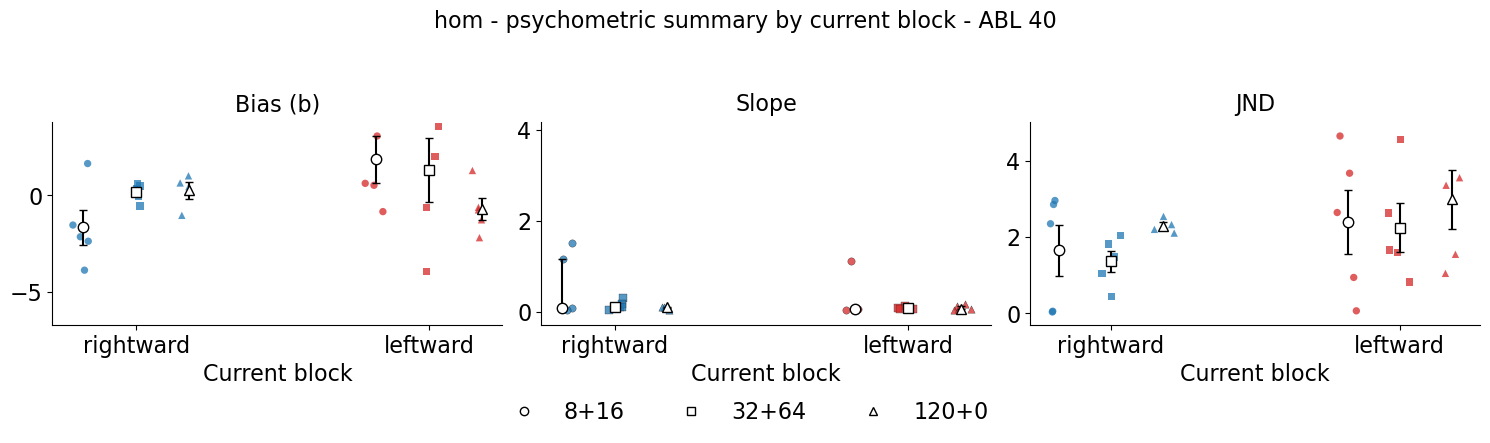

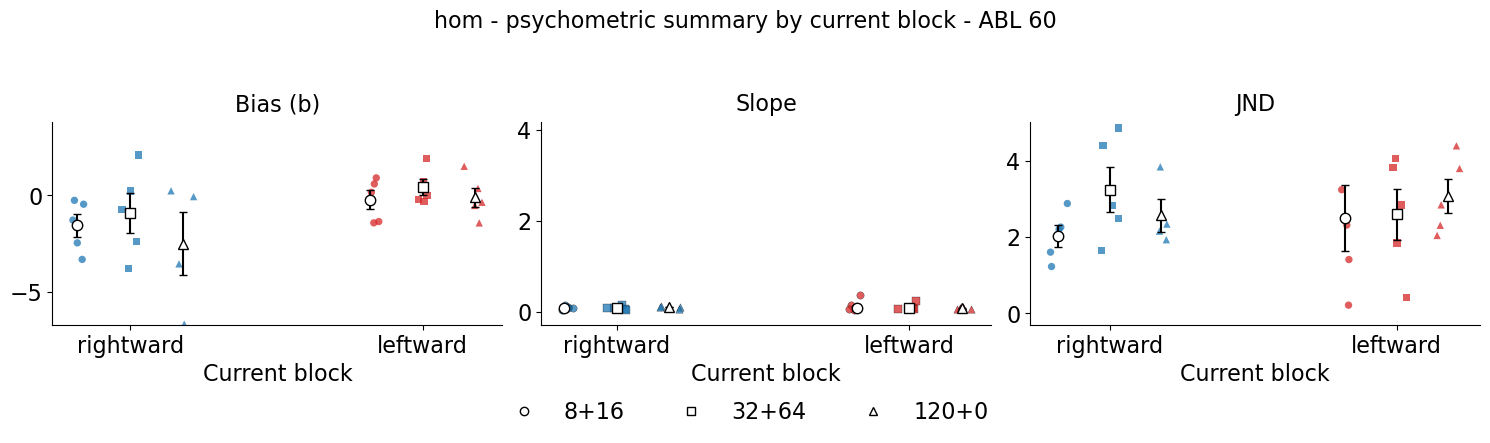

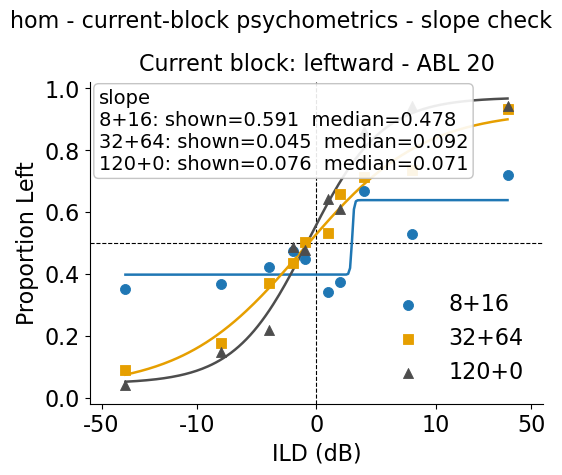

Current-block suspicious slope values


,condition_type,condition,ABL,duration_pair,slope_metric,slope_summary,slope_summary_type,n_animals_with_slope,used_trimmed_mean
0,current_block_condition,leftward,20,8+16,effective_slope,0.477795,median,4,<NA>
1,current_block_condition,leftward,20,8+16,displayed_curve_slope,0.591177,displayed_curve,<NA>,<NA>
2,current_block_condition,leftward,20,32+64,effective_slope,0.092337,median,5,<NA>
3,current_block_condition,leftward,20,32+64,displayed_curve_slope,0.044852,displayed_curve,<NA>,<NA>
4,current_block_condition,leftward,20,120+0,effective_slope,0.071275,median,5,<NA>
5,current_block_condition,leftward,20,120+0,displayed_curve_slope,0.075633,displayed_curve,<NA>,<NA>


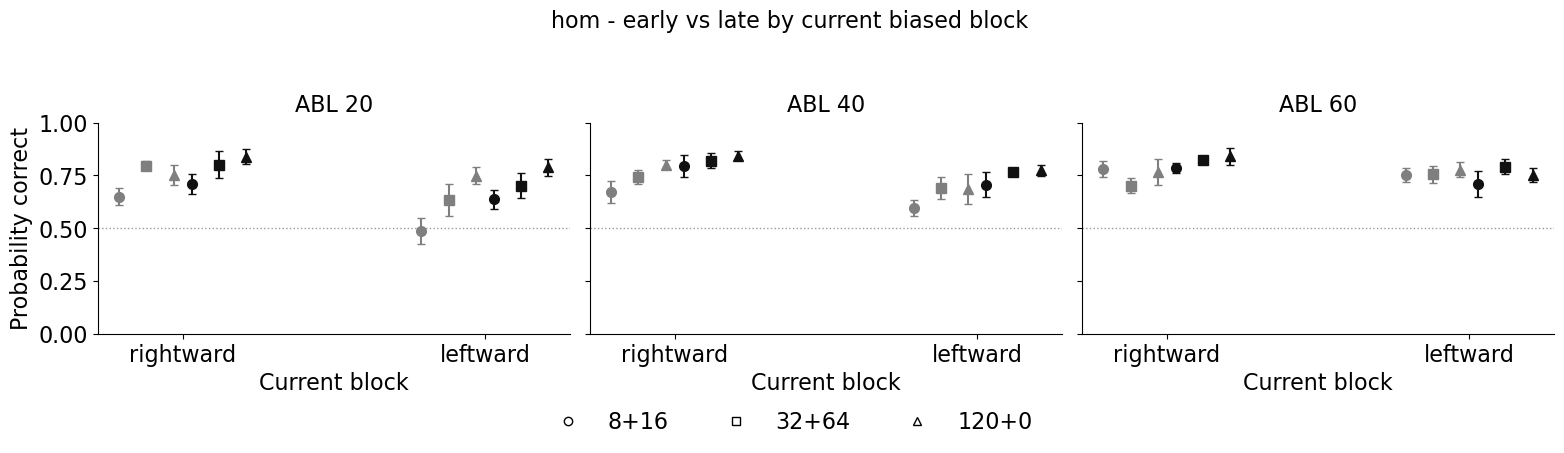

history figures rendered


In [9]:
import importlib
import matplotlib.pyplot as plt
from IPython.display import display

bb = importlib.reload(bb)

def figure_signature(fig):
    suptitle = fig._suptitle.get_text() if getattr(fig, '_suptitle', None) is not None else ''
    axes_bits = []
    for ax in fig.axes:
        axes_bits.append((
            ax.get_title(),
            ax.get_xlabel(),
            ax.get_ylabel(),
            tuple(t.get_text() for t in ax.get_xticklabels()),
            tuple(t.get_text() for t in ax.get_yticklabels()),
            len(ax.lines),
            len(ax.collections),
        ))
    return (suptitle, tuple(axes_bits))

seen_figure_signatures = set()

def display_and_close(fig):
    sig = figure_signature(fig)
    if sig in seen_figure_signatures:
        plt.close(fig)
        return
    seen_figure_signatures.add(sig)
    display(fig)
    plt.close(fig)

HISTORY_PLOT_VIEW = None      # set to a view name to plot just one selected group/view
HISTORY_ABLS = (20, 40, 60)
HISTORY_EARLY_N = 10         # first N valid trials in the current biased block
HISTORY_LATE_N = 10          # last N valid trials in the current biased block
HISTORY_DURATION_GROUPS = ((8, 16), (32, 64), (120, 0))

history_views = [v for v in views if HISTORY_PLOT_VIEW is None or v.name == HISTORY_PLOT_VIEW]
if not history_views:
    raise ValueError(f"HISTORY_PLOT_VIEW={HISTORY_PLOT_VIEW!r} did not match any selected view.")

plt.close('all')

with plt.ioff():
    history_out = bb.plot_block_history_exploration(
        bundle=bundle,
        views=history_views,
        abls=HISTORY_ABLS,
        early_n=HISTORY_EARLY_N,
        late_n=HISTORY_LATE_N,
        duration_groups=HISTORY_DURATION_GROUPS,
        show=False,
    )

for view_name, payload in history_out.items():
    print(view_name, payload.get("status", {}))
    if payload.get("performance_figure") is not None:
        display_and_close(payload["performance_figure"])
    for fig in payload.get("psy_param_figures", {}).values():
        display_and_close(fig)
    for fig in payload.get("diagnostic_psychometric_figures", {}).values():
        display_and_close(fig)
    if payload.get("diagnostic_slope_table") is not None and not payload["diagnostic_slope_table"].empty:
        print("Previous/current suspicious slope values")
        display(payload["diagnostic_slope_table"])
    if payload.get("phase_figure") is not None:
        display_and_close(payload["phase_figure"])
    if payload.get("current_performance_figure") is not None:
        display_and_close(payload["current_performance_figure"])
    for fig in payload.get("current_psy_param_figures", {}).values():
        display_and_close(fig)
    for fig in payload.get("current_diagnostic_psychometric_figures", {}).values():
        display_and_close(fig)
    if payload.get("current_diagnostic_slope_table") is not None and not payload["current_diagnostic_slope_table"].empty:
        print("Current-block suspicious slope values")
        display(payload["current_diagnostic_slope_table"])
    if payload.get("current_phase_figure") is not None:
        display_and_close(payload["current_phase_figure"])

plt.close('all')
print("history figures rendered")


## 9. Experimental Fit Check

In [ ]:
import contextlib
import io

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import Psychometric
from GroupComparison.prepare import prep_psy

FIT_CHECK_VIEW = "wt"                 # e.g. "wt", "het", "hom"
FIT_CHECK_MODE = "previous_current"   # "previous_current" or "current_block"
FIT_CHECK_CONDITION = "R->L"          # e.g. "U->R", "L->R", "U->L", "R->L", or "rightward" / "leftward"
FIT_CHECK_ABL = 20
FIT_CHECK_DURATION_PAIR = "8+16"      # "8+16", "32+64", "120+0"
FIT_CHECK_ANIMALS = None               # e.g. ["ASD0040", "ASD0042"] or None for all

fit_view = next((v for v in views if v.name == FIT_CHECK_VIEW), None)
if fit_view is None:
    raise ValueError(f"FIT_CHECK_VIEW={FIT_CHECK_VIEW!r} did not match any selected view.")

history_df = bb._history_transition_rows(
    fit_view.selector(bundle["df_blocks"]),
    duration_groups=HISTORY_DURATION_GROUPS if "HISTORY_DURATION_GROUPS" in globals() else ((8, 16), (32, 64), (120, 0)),
)
if history_df.empty:
    raise ValueError("No history-transition rows available for the selected view.")

if FIT_CHECK_MODE == "previous_current":
    cond_col = "transition_type"
elif FIT_CHECK_MODE == "current_block":
    cond_col = "current_block_condition"
else:
    raise ValueError("FIT_CHECK_MODE must be 'previous_current' or 'current_block'.")

fit_df = history_df[
    (history_df[cond_col].astype(str) == str(FIT_CHECK_CONDITION))
    & (history_df["duration_pair"].astype(str) == str(FIT_CHECK_DURATION_PAIR))
].copy()
if FIT_CHECK_ANIMALS is not None:
    fit_df = fit_df[fit_df["animal"].astype(str).isin([str(a) for a in FIT_CHECK_ANIMALS])].copy()
if fit_df.empty:
    raise ValueError("No rows matched the selected fit-check subset.")

with contextlib.redirect_stdout(io.StringIO()):
    psy_points, _, _, _, _, _ = prep_psy(
        fit_df,
        do_individual_fits=False,
        aggregation=bundle["cfg"].psychometric_aggregation,
        skip_jnd_abl=50,
    )

value_col = "mean" if "mean" in psy_points.columns else "PropLeft"
animal_points = psy_points[pd.to_numeric(psy_points["ABL"], errors="coerce").eq(int(FIT_CHECK_ABL))].copy()
if animal_points.empty:
    raise ValueError("No psychometric points available for that ABL in the selected subset.")

animal_points["ILD"] = pd.to_numeric(animal_points["ILD"], errors="coerce")
animal_points[value_col] = pd.to_numeric(animal_points[value_col], errors="coerce")
animal_points = animal_points.dropna(subset=["subject", "ILD", value_col]).copy()
animal_points = animal_points.sort_values(["subject", "ILD"])

def weighted_rss(y_true, y_hat, w):
    finite = np.isfinite(y_true) & np.isfinite(y_hat) & np.isfinite(w)
    if not finite.any():
        return np.nan
    return float(np.sum((w[finite] * (y_true[finite] - y_hat[finite])) ** 2))

def aic_from_rss(rss, n, k):
    if not np.isfinite(rss) or rss <= 0 or n <= k:
        return np.nan
    return float(n * np.log(rss / n) + 2 * k)

fit_rows = []
curve_payloads = []
for animal, sub in animal_points.groupby("subject", sort=True):
    sub = sub.copy().sort_values("ILD")
    x = sub["ILD"].to_numpy(dtype=float)
    y = sub[value_col].to_numpy(dtype=float)
    if len(x) < 2:
        continue
    w = np.ones_like(x, dtype=float)

    line_coef = np.polyfit(x, y, deg=1, w=w)
    line_slope = float(line_coef[0])
    line_intercept = float(line_coef[1])
    line_pred = line_slope * x + line_intercept
    line_rss = weighted_rss(y, line_pred, w)
    line_aic = aic_from_rss(line_rss, len(x), 2)

    psy_pars = psy_xx = psy_yy = None
    psy_slope = np.nan
    psy_pred = np.full_like(y, np.nan, dtype=float)
    psy_rss = np.nan
    psy_aic = np.nan
    if len(x) >= 4:
        try:
            psy_pars, _, psy_xx, psy_yy = Psychometric.fit_and_plot_psychometric(
                x,
                y,
                model="my_psycho",
                n_trials=np.full(len(x), 1, dtype=int),
                show_plot=False,
            )
            psy_pred = Psychometric.my_psycho_model(x, *psy_pars)
            xx_dense = np.linspace(float(x.min()), float(x.max()), 800)
            yy_dense = Psychometric.my_psycho_model(xx_dense, *psy_pars)
            psy_slope = float(np.interp(0.0, xx_dense, np.gradient(yy_dense, xx_dense)))
            psy_rss = weighted_rss(y, psy_pred, w)
            psy_aic = aic_from_rss(psy_rss, len(x), 4)
        except Exception:
            psy_pars = psy_xx = psy_yy = None

    preferred_model = "psychometric"
    chosen_slope = psy_slope
    if not np.isfinite(psy_aic):
        preferred_model = "line"
        chosen_slope = line_slope
    elif np.isfinite(line_aic) and line_aic <= psy_aic:
        preferred_model = "line"
        chosen_slope = line_slope

    fit_rows.append({
        "animal": animal,
        "n_ild_points": len(x),
        "line_rss": line_rss,
        "line_aic": line_aic,
        "line_slope_at_0": line_slope,
        "psychometric_rss": psy_rss,
        "psychometric_aic": psy_aic,
        "psychometric_slope_at_0": psy_slope,
        "preferred_model": preferred_model,
        "chosen_slope_at_0": chosen_slope,
    })
    curve_payloads.append({
        "animal": animal,
        "x": x,
        "y": y,
        "line_slope": line_slope,
        "line_intercept": line_intercept,
        "psy_xx": psy_xx,
        "psy_yy": psy_yy,
        "preferred_model": preferred_model,
    })

fit_summary = pd.DataFrame(fit_rows).sort_values("animal")
if fit_summary.empty:
    raise ValueError("No animal had enough ILD points for the selected fit check.")

display(animal_points[["subject", "ABL", "ILD", value_col]].rename(columns={"subject": "animal", value_col: "prop_right"}))
display(fit_summary)
display(fit_summary["preferred_model"].value_counts().rename_axis("preferred_model").reset_index(name="n_animals"))

n_panels = len(curve_payloads)
n_cols = min(3, max(1, n_panels))
n_rows = int(np.ceil(n_panels / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.0 * n_cols, 4.2 * n_rows), squeeze=False)
flat_axes = axes.ravel()
for ax, payload in zip(flat_axes, curve_payloads):
    x = payload["x"]
    y = payload["y"]
    ax.scatter(x, y, s=45, color="black", zorder=5, label="Observed")
    xx_line = np.linspace(float(x.min()), float(x.max()), 300)
    yy_line = payload["line_slope"] * xx_line + payload["line_intercept"]
    ax.plot(xx_line, yy_line, color="#D55E00", linewidth=1.8, label="Line")
    if payload["psy_xx"] is not None and payload["psy_yy"] is not None:
        ax.plot(payload["psy_xx"], payload["psy_yy"], color="#0072B2", linewidth=1.8, label="Psychometric")
    ax.axvline(0, color="0.45", linestyle="--", linewidth=1.0)
    ax.axhline(0.5, color="0.6", linestyle=":", linewidth=1.0)
    ax.set_ylim(-0.02, 1.02)
    ax.set_title(f"{payload['animal']} | preferred: {payload['preferred_model']}", fontsize=11)
    ax.set_xlabel("ILD (dB)")
    ax.set_ylabel("Proportion Right")
    for spine in ["right", "top"]:
        ax.spines[spine].set_visible(False)
for ax in flat_axes[n_panels:]:
    ax.axis("off")
handles, labels = flat_axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False)
fig.suptitle(
    f"{FIT_CHECK_VIEW} | {FIT_CHECK_MODE} | {FIT_CHECK_CONDITION} | ABL {FIT_CHECK_ABL} | {FIT_CHECK_DURATION_PAIR}",
    fontsize=13,
    y=0.99,
)
fig.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()


## 10. Optional Save For Google Slides

In [ ]:
SAVE_FIGURES = False

if SAVE_FIGURES:
    out_dir = ROOT / "outputs" / "biased_blocks"
    bb.save_biased_block_figures(out["figures"], out_dir, prefix=f"biased_blocks_{LAYOUT}")
    print(out_dir)